# **Problem Statement**
Insurance companies need to accurately predict the cost of health insurance for individuals to set premiums appropriately. However, traditional methods of cost prediction often rely on broad actuarial tables and historical averages, which may not account for the nuanced differences among individuals. By leveraging machine learning techniques, insurers can predict more accurately the insurance costs tailored to individual profiles, leading to more competitive pricing and better risk management.

## **Insurance Cost Prediction need**
The primary need for this project arises from the challenges insurers face in pricing policies accurately while remaining competitive in the market. Inaccurate predictions can lead to losses for insurers and unfairly high premiums for policyholders. By implementing a machine learning model, insurers can:

*   Enhance Precision in Pricing: Use individual data points to determine premiums that reflect actual risk more closely than generic estimates.
*   Increase Competitiveness: Offer rates that are attractive to consumers while ensuring that the pricing is sustainable for the insurer.
*  Improve Customer Satisfaction: Fair and transparent pricing based on personal health data can increase trust and satisfaction among policyholders.
*  Enable Personalized Offerings: Create customized insurance packages based on predicted costs, which can cater more directly to the needs and preferences of individuals.
*  Risk Assessment: Insurers can use the model to refine their risk assessment processes, identifying key factors that influence costs most significantly.
*  Policy Development: The insights gained from the model can inform the development of new insurance products or adjustments to existing ones.
*  Strategic Decision Making: Predictive analytics can aid in broader strategic decisions, such as entering new markets or adjusting policy terms based on risk predictions.
*  Customer Engagement: Insights from the model can be used in customer engagement initiatives, such as personalized marketing and tailored advice for policyholders.

## **Data description**
The dataset comprises the following 11 attributes:

	1.	Age: Numeric, ranging from 18 to 66 years.
	2.	Diabetes: Binary (0 or 1), where 1 indicates the presence of diabetes.
	3.	BloodPressureProblems: Binary (0 or 1), indicating the presence of blood pressure-related issues.
	4.	AnyTransplants: Binary (0 or 1), where 1 indicates the person has had a transplant.
	5.	AnyChronicDiseases: Binary (0 or 1), indicating the presence of any chronic diseases.
	6.	Height: Numeric, measured in centimeters, ranging from 145 cm to 188 cm.
	7.	Weight: Numeric, measured in kilograms, ranging from 51 kg to 132 kg.
	8.	KnownAllergies: Binary (0 or 1), where 1 indicates known allergies.
	9.	HistoryOfCancerInFamily: Binary (0 or 1), indicating a family history of cancer.
	10.	NumberOfMajorSurgeries: Numeric, counting the number of major surgeries, ranging from 0 to 3 surgeries.
	11.	PremiumPrice: Numeric, representing the premium price in currency, ranging from 15,000 to 40,000.




In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import itertools
import math

from scipy.stats import shapiro, ttest_ind, f_oneway, kruskal, chi2_contingency

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.linear_model import LinearRegression, Lasso, Ridge
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.stats.api as sms
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error

from sklearn.neighbors import KNeighborsRegressor

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 100)

In [4]:
insurance_df = pd.read_csv("insurance.csv")

# **STEP 1: DATA QUALITY REPORT** (Observations on Data)

In [5]:
#PRINT SAMPLE RECORDS
print("Sample records:")
sample = insurance_df.sample(n=20,axis=0, random_state=32)
display(sample)

Sample records:


,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
109,64,1,0,0,0,187,53,0,0,3,28000
475,41,1,1,0,0,167,70,0,0,1,23000
757,44,0,0,0,0,176,60,1,0,0,23000
435,37,1,0,0,0,174,63,1,1,1,31000
746,24,0,0,1,0,176,83,0,0,0,15000
822,18,0,1,0,0,163,82,0,0,0,15000
415,31,1,0,0,0,162,73,0,0,0,23000
92,52,0,0,0,0,159,76,1,1,1,31000
809,48,0,0,0,1,161,95,0,0,1,35000
190,30,0,1,0,0,174,91,0,0,0,23000


In [6]:
def data_quality_report(df):

  # DATA REPORT (STRUCTURE & CHARACTERISTICS)
  print("*"*150)
  print("Shape:")
  n_obs = df.shape[0]
  n_features = df.shape[1]
  display(f"No. of observations: {n_obs}, No. of features:{n_features}")
  print("\n Duplicates : ")
  display(f"No. of duplicated rows: {df.duplicated().sum()}")

  print("*"*150)
  print("Initial Summary Stats:")
  names = df.columns
  dtypes = df.dtypes
  missing = df.isnull().sum()
  non_missing = df.notnull().sum()
  missing_pct = (missing / len(df)) * 100
  unique = df.nunique()

  list_of_tuples = list(zip(names, dtypes, missing, non_missing, missing_pct, unique, ))
  summary_df = pd.DataFrame(list_of_tuples,columns=['name', 'data_type', 'missing', 'non-missing', 'missing_pct','unique'])
  display(summary_df.round(2))

  return n_obs, n_features, summary_df

In [7]:
n_obs, n_features, summary_df = data_quality_report(insurance_df)

******************************************************************************************************************************************************
Shape:


'No. of observations: 986, No. of features:11'


 Duplicates : 


'No. of duplicated rows: 0'

******************************************************************************************************************************************************
Initial Summary Stats:


,name,data_type,missing,non-missing,missing_pct,unique
0,Age,int64,0,986,0.0,49
1,Diabetes,int64,0,986,0.0,2
2,BloodPressureProblems,int64,0,986,0.0,2
3,AnyTransplants,int64,0,986,0.0,2
4,AnyChronicDiseases,int64,0,986,0.0,2
5,Height,int64,0,986,0.0,44
6,Weight,int64,0,986,0.0,74
7,KnownAllergies,int64,0,986,0.0,2
8,HistoryOfCancerInFamily,int64,0,986,0.0,2
9,NumberOfMajorSurgeries,int64,0,986,0.0,4


Based on the intital data quality report:


*   No. of Observations : 986
*   No. of Variables : 11
*   Duplicate rows : No
*   Missing values : No Missing data
*   Data type : All variables are of integer data type.






In [8]:
insurance_df.columns

Index(['Age', 'Diabetes', 'BloodPressureProblems', 'AnyTransplants',
       'AnyChronicDiseases', 'Height', 'Weight', 'KnownAllergies',
       'HistoryOfCancerInFamily', 'NumberOfMajorSurgeries', 'PremiumPrice'],
      dtype='object')

In [9]:
num_vars = list(['Age',
                 'Height',
                 'Weight',
                 'PremiumPrice'])

cat_vars = list(['Diabetes',
                 'BloodPressureProblems',
                 'AnyTransplants',
                 'AnyChronicDiseases',
                 'KnownAllergies',
                 'HistoryOfCancerInFamily',
                 'NumberOfMajorSurgeries',])

target = 'PremiumPrice'


# **STEP 2: UNIVARIATE ANALYSIS**

In [10]:
class EDAUnivariateAnalysis:
  """
  Comprehensive EDA Framework for Univariate Analysis
  """
  def __init__(self, df, cat_vars, num_vars):
    self.df = df.copy()
    self.cat_vars = cat_vars
    self.num_vars = num_vars

# NUMERICAL STATS
  def numeric_analysis(self):
    print("Numerical Analysis:")
    print("*"*250)

    # num_vars = self.num_vars
    num_df = self.df[self.num_vars]

    numeric_stats = num_df.describe(percentiles=[.01, 0.05, 0.1, .25, .5, .75, .8, .9, .95, .99]).T.round(2)
    numeric_stats.rename(columns={'index' : 'name'},inplace=True)

    numeric_stats['skew'] = num_df.skew()
    numeric_stats['kurt'] = num_df.kurt()

    return numeric_stats.round(2)

    #OUTLIER DETECTION
  def outlier_detection(self):
    print("*"*250)
    print("Outlier Detection:")
    num_df = self.df[num_vars]
    outlier_lst = []
    for col in num_vars:
      mean = num_df[col].mean()
      std = num_df[col].std()
      Q1 = num_df[col].quantile(0.25)
      Q3 = num_df[col].quantile(0.75)
      IQR = Q3 - Q1
      IQR_LB = Q1 - 1.5 * IQR
      IQR_UB = Q3 + 1.5 * IQR
      ZScore_LB = mean - 3 * std
      ZScore_UB = mean + 3 * std
      IQR_outlier_cnt = ((num_df[col] < IQR_LB) | (num_df[col] > IQR_UB)).sum()
      ZScore_outlier_cnt = ((num_df[col] < ZScore_LB) | (num_df[col] > ZScore_UB)).sum()

      outlier_dict = {
          'IQR' : IQR,
          'IQR_LB' : IQR_LB,
          'IQR_UB' : IQR_UB,
          'ZScore_LB' : ZScore_LB,
          'ZScore_UB' : ZScore_UB,
          'IQR_outlier_cnt' : IQR_outlier_cnt,
          'ZScore_outlier_cnt' : ZScore_outlier_cnt,
      }
      outlier_lst.append(outlier_dict)

    outlier_stats = pd.DataFrame(outlier_lst,index=num_vars)

    outliers_IQR = (
        (num_df[num_vars] < outlier_stats['IQR_LB']) | (num_df[num_vars] > outlier_stats['IQR_UB'])).any(axis=1).sum()

    outliers_ZScore = (
        (num_df < outlier_stats['ZScore_LB']) | (num_df > outlier_stats['ZScore_UB'])).any(axis=1).sum()

    print("\nTotal outliers using IQR : ", outliers_IQR)
    print("Total outliers using ZScore : ", outliers_ZScore)

    return outlier_stats.round(2)

  def graphical_num(self):
    print("="*250)
    print("Histogram / Box plot for Continous Variables: ")
    num_vars = self.num_vars
    for col in num_vars:
      fig, axes = plt.subplots(1, 2, figsize=(12,4))

      #plot histogram
      sns.histplot(data=self.df, x=col, kde=True, stat='density',line_kws={'linewidth': 3}, ax=axes[0])
      axes[0].set_title(f"Histogram of {col}")
      axes[0].set_xlabel("")

      #plot boxplot
      sns.boxplot(data=self.df, x = col, ax=axes[1])
      axes[1].set_title(f"Box plot of {col}")
      axes[1].set_xlabel("")

      plt.tight_layout()

    plt.show()

###################################################################################################

  def categoric_analysis(self):
    print("*"*150)
    print("Categorical Analysis:")
    category_df = pd.DataFrame()
    for col in self.cat_vars:
      temp_df_1 = self.df[col].value_counts(dropna=False).reset_index()
      temp_df_2 = self.df[col].value_counts(dropna=False,normalize=True).reset_index()

      print("*"*150)
      # print(f"Frequency Distribution for {col}:")
      temp_df = pd.merge(temp_df_1, temp_df_2, how='inner', on=col)
      display(temp_df.round(2))

    print("="*250)
    print("Count Plot for Discrete variables: ")
    cat_vars = self.cat_vars
    cols = 2
    rows = (len(cat_vars) // cols) + (len(cat_vars) % cols)

    fig, axs = plt.subplots(nrows= rows, ncols= cols, figsize=(20,16))
    fig.subplots_adjust(top=1.3)
    count = 0
    for row in range(rows):
      for col in range(cols):
        sns.countplot(data=self.df, x=cat_vars[count], ax=axs[row, col], palette='Set2',legend=False)
        axs[row, col].set_title(f"{cat_vars[count]}", pad=12, fontsize=16)
        axs[row, col].set_xlabel(None)
        axs[row, col].set_ylabel(None)
        axs[row, col].tick_params(axis='x', labelrotation=45)
        count += 1
        if count == len(cat_vars):
          break

    plt.show()

  ###################################################################################################


In [11]:
eda_univariate = EDAUnivariateAnalysis(insurance_df, cat_vars, num_vars)

In [12]:
numeric_stats = eda_univariate.numeric_analysis()
display(numeric_stats)

outlier_stats = eda_univariate.outlier_detection()
display(outlier_stats)

Numerical Analysis:
**********************************************************************************************************************************************************************************************************************************************************


,count,mean,std,min,1%,5%,10%,25%,50%,75%,80%,90%,95%,99%,max,skew,kurt
Age,986.0,41.75,13.96,18.0,18.00,20.0,22.0,30.0,42.0,53.0,56.0,62.0,64.0,66.0,66.0,0.03,-1.13
Height,986.0,168.18,10.10,145.0,147.00,150.0,154.0,161.0,168.0,176.0,178.0,182.0,184.0,186.0,188.0,-0.18,-0.76
Weight,986.0,76.95,14.27,51.0,52.85,57.0,59.0,67.0,75.0,87.0,89.0,95.0,99.0,121.0,132.0,0.67,0.61
PremiumPrice,986.0,24336.71,6248.18,15000.0,15000.00,15000.0,15000.0,21000.0,23000.0,28000.0,29000.0,31000.0,35000.0,38000.0,40000.0,0.10,-0.45


**********************************************************************************************************************************************************************************************************************************************************
Outlier Detection:

Total outliers using IQR :  21
Total outliers using ZScore :  13


,IQR,IQR_LB,IQR_UB,ZScore_LB,ZScore_UB,IQR_outlier_cnt,ZScore_outlier_cnt
Age,23.0,-4.5,87.5,-0.14,83.64,0,0
Height,15.0,138.5,198.5,137.89,198.48,0,0
Weight,20.0,37.0,117.0,34.16,119.75,16,13
PremiumPrice,7000.0,10500.0,38500.0,5592.16,43081.27,6,0


Histogram / Box plot for Continous Variables: 


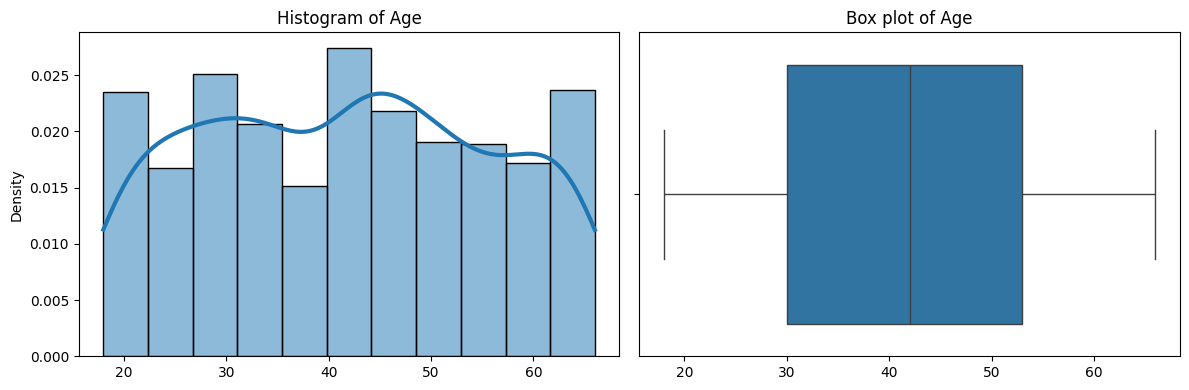

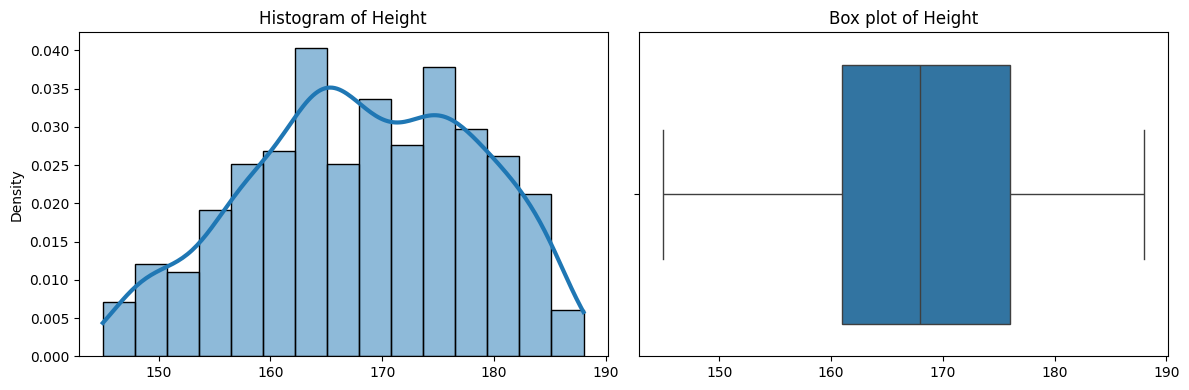

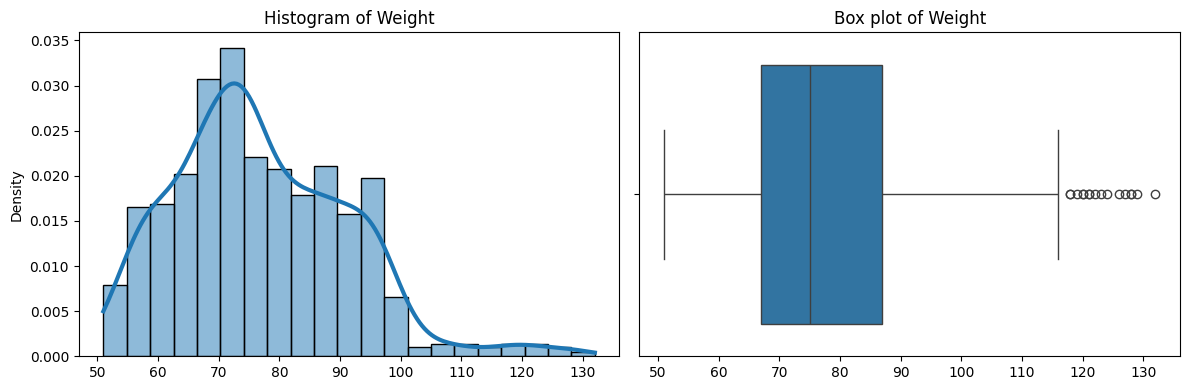

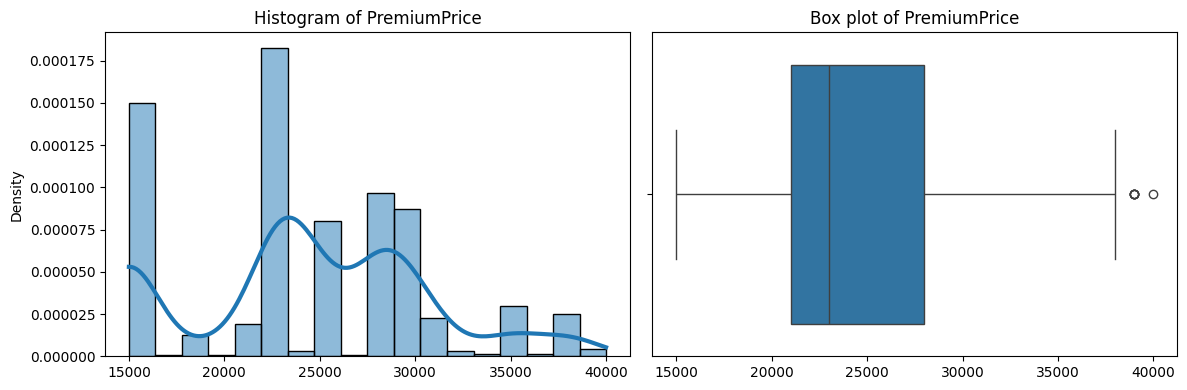

In [13]:
eda_univariate.graphical_num()

******************************************************************************************************************************************************
Categorical Analysis:
******************************************************************************************************************************************************


,Diabetes,count,proportion
0,0,572,0.58
1,1,414,0.42


******************************************************************************************************************************************************


,BloodPressureProblems,count,proportion
0,0,524,0.53
1,1,462,0.47


******************************************************************************************************************************************************


...

******************************************************************************************************************************************************


,HistoryOfCancerInFamily,count,proportion
0,0,870,0.88
1,1,116,0.12


******************************************************************************************************************************************************


,NumberOfMajorSurgeries,count,proportion
0,0,479,0.49
1,1,372,0.38
2,2,119,0.12
3,3,16,0.02


Count Plot for Discrete variables: 


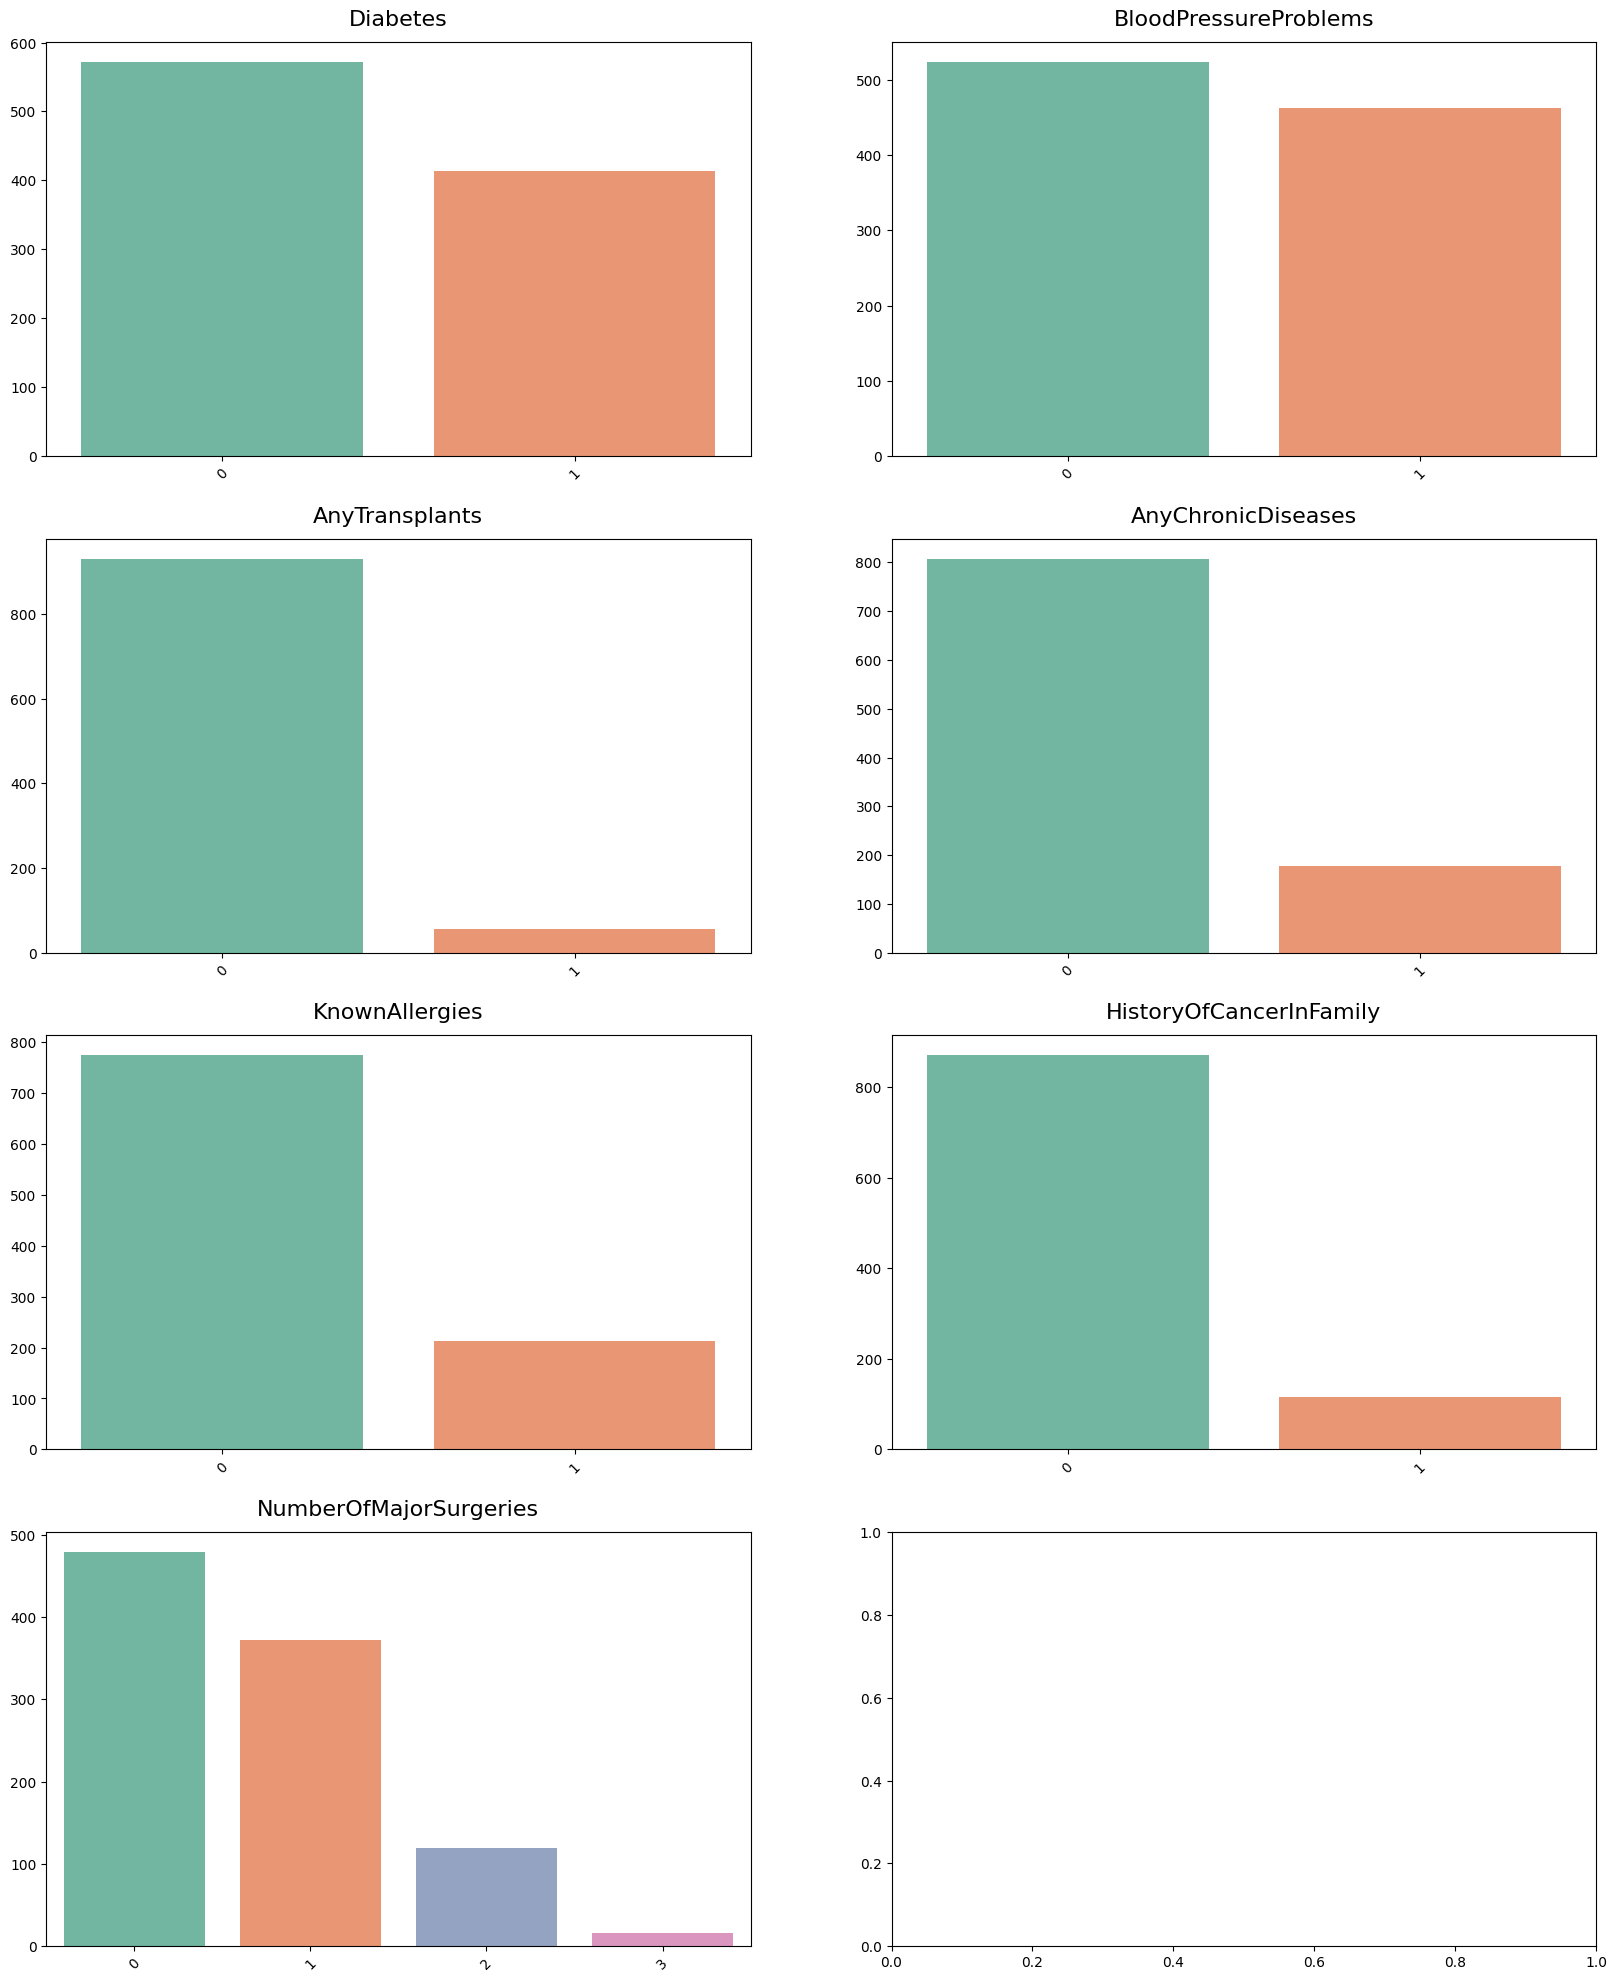

In [14]:
eda_univariate.categoric_analysis()

# **STEP 3: BIVARIATE ANALYSIS**

In [15]:
class EDABivariateAnalysis(EDAUnivariateAnalysis):
  """
  Comprehensive EDA Framework for Bivariate Analysis
  """

  def __init__(self,df, cat_vars, num_vars, target):
    super().__init__(df, cat_vars, num_vars)
    self.target = target

#######################################################################################
  #####CORRELATION MATRIX####
#######################################################################################
  def corr_matrix(self):
    num_vars = self.num_vars

    correlation_matrix = self.df[num_vars].corr(method='pearson')
    correlation_matrix_2 = self.df[num_vars].corr(method='spearman')

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',fmt=".2f", linewidths=.5, ax=axes[0])
    axes[0].set_title('Pearson')

    sns.heatmap(correlation_matrix_2, annot=True, cmap='coolwarm',fmt=".2f", linewidths=.5, ax=axes[1])
    axes[1].set_title('Spearman')

    fig.suptitle('Correlation Matrix')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    plt.show()

    return correlation_matrix

#######################################################################################
  #####GROUP BY STATS####
#######################################################################################

  def grouped_numeric_analysis(self):
    for col in self.cat_vars:
      print(f"Group by variable: {col}, Analysis variable : {self.target}\n")
      display(self.df.groupby(col)[self.target].describe().round(2).reset_index())
      print("#"*200)

#######################################################################################
  #####REG PLOT####
#######################################################################################
  def regplot(self):
    num_vars = self.num_vars
    num_pairs = list(itertools.combinations(num_vars,2))
    # print(num_pairs)
    nplots = len(num_pairs)
    ncols = 3
    nrows = math.ceil(nplots/ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*5))
    # Flatten the axes array if it's a 2D array for easy iteration
    if nrows > 1:
      axes = axes.flatten()
    elif nrows == 1:
      # If only one row, axes might be a single array, but can be a scalar if only 1 plot
      if nplots == 1:
        axes = [axes]

    # Iterate through all pairs and plot on respective axes

    for i, (col1, col2) in enumerate(num_pairs):
      ax = axes[i]
      sns.regplot(data=self.df, x=col1, y=col2, ax=ax, color='gray',line_kws=dict(color="red"))
      ax.set_title(f'{col1} Vs {col2}', fontweight='bold')
      ax.grid(True)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
      fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.suptitle('Regression Plots for All Numeric Combinations', fontsize=14, fontweight='bold')
    plt.show()

#######################################################################################
  #####BOX PLOT####
#######################################################################################
  def boxplot(self):
    ncols = 2
    nrows = math.ceil(len(self.cat_vars) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 5))
    axes = axes.flatten()  # Flatten to iterate easily


    for i, var in enumerate(self.cat_vars):
      sns.boxplot(x=var, y=self.target, data=self.df, ax=axes[i], hue=var)
      axes[i].set_title(f'{var} vs {target}')
      axes[i].set_xlabel('')
      axes[i].tick_params(axis='x', rotation=45)

# Remove empty subplots if any
    for j in range(i + 1, len(axes)):
      fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()



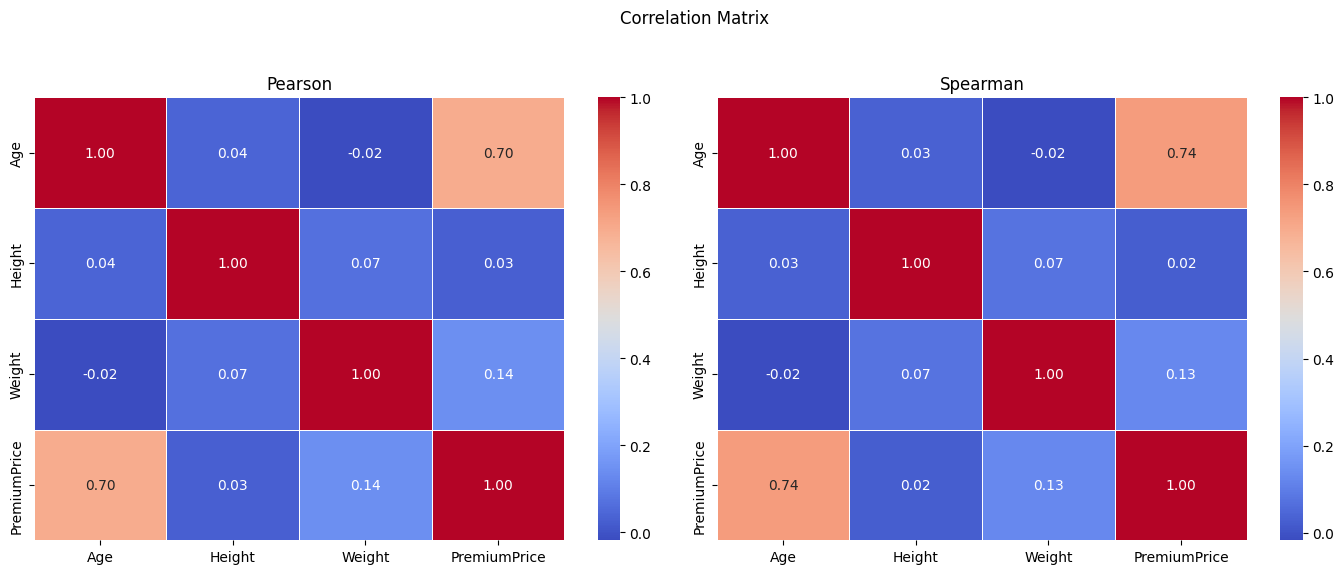

In [16]:
eda_2 = EDABivariateAnalysis(insurance_df, cat_vars, num_vars, target)
correlation_matrix = eda_2.corr_matrix()

In [17]:
eda_2.grouped_numeric_analysis()

Group by variable: Diabetes, Analysis variable : PremiumPrice



,Diabetes,count,mean,std,min,25%,50%,75%,max
0,0,572.0,23931.82,6562.96,15000.0,19000.0,23000.0,29000.0,39000.0
1,1,414.0,24896.14,5746.15,15000.0,23000.0,25000.0,28000.0,40000.0


########################################################################################################################################################################################################
Group by variable: BloodPressureProblems, Analysis variable : PremiumPrice



,BloodPressureProblems,count,mean,std,min,25%,50%,75%,max
0,0,524.0,23356.87,6605.85,15000.0,15000.0,23000.0,28000.0,39000.0
1,1,462.0,25448.05,5619.58,15000.0,23000.0,25000.0,28000.0,40000.0


########################################################################################################################################################################################################
Group by variable: AnyTransplants, Analysis variable : PremiumPrice



...

########################################################################################################################################################################################################
Group by variable: HistoryOfCancerInFamily, Analysis variable : PremiumPrice



,HistoryOfCancerInFamily,count,mean,std,min,25%,50%,75%,max
0,0,870.0,24147.13,6117.86,15000.0,21500.0,23000.0,28000.0,40000.0
1,1,116.0,25758.62,7017.52,15000.0,21000.0,28000.0,31000.0,39000.0


########################################################################################################################################################################################################
Group by variable: NumberOfMajorSurgeries, Analysis variable : PremiumPrice



,NumberOfMajorSurgeries,count,mean,std,min,25%,50%,75%,max
0,0,479.0,22968.68,6356.98,15000.0,15000.0,23000.0,25000.0,39000.0
1,1,372.0,24741.94,6593.97,15000.0,21000.0,25000.0,29250.0,39000.0
2,2,119.0,28084.03,1175.89,24000.0,28000.0,28000.0,28000.0,40000.0
3,3,16.0,28000.00,0.00,28000.0,28000.0,28000.0,28000.0,28000.0


########################################################################################################################################################################################################


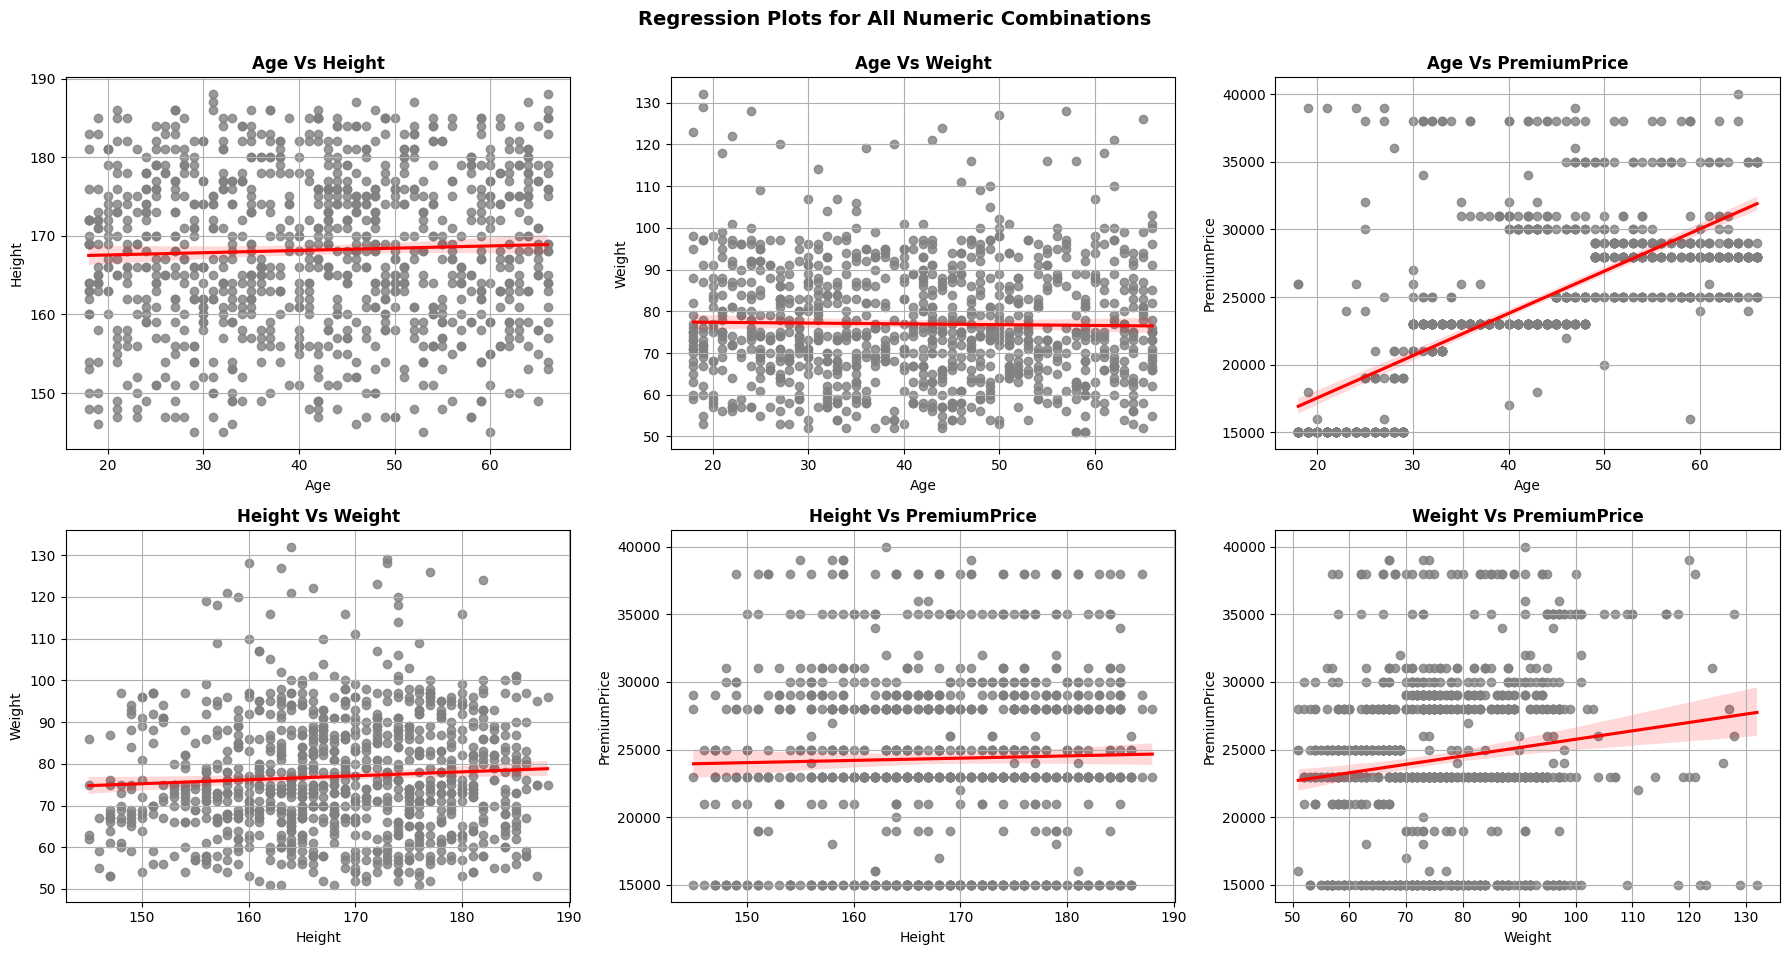

In [18]:
eda_2.regplot()

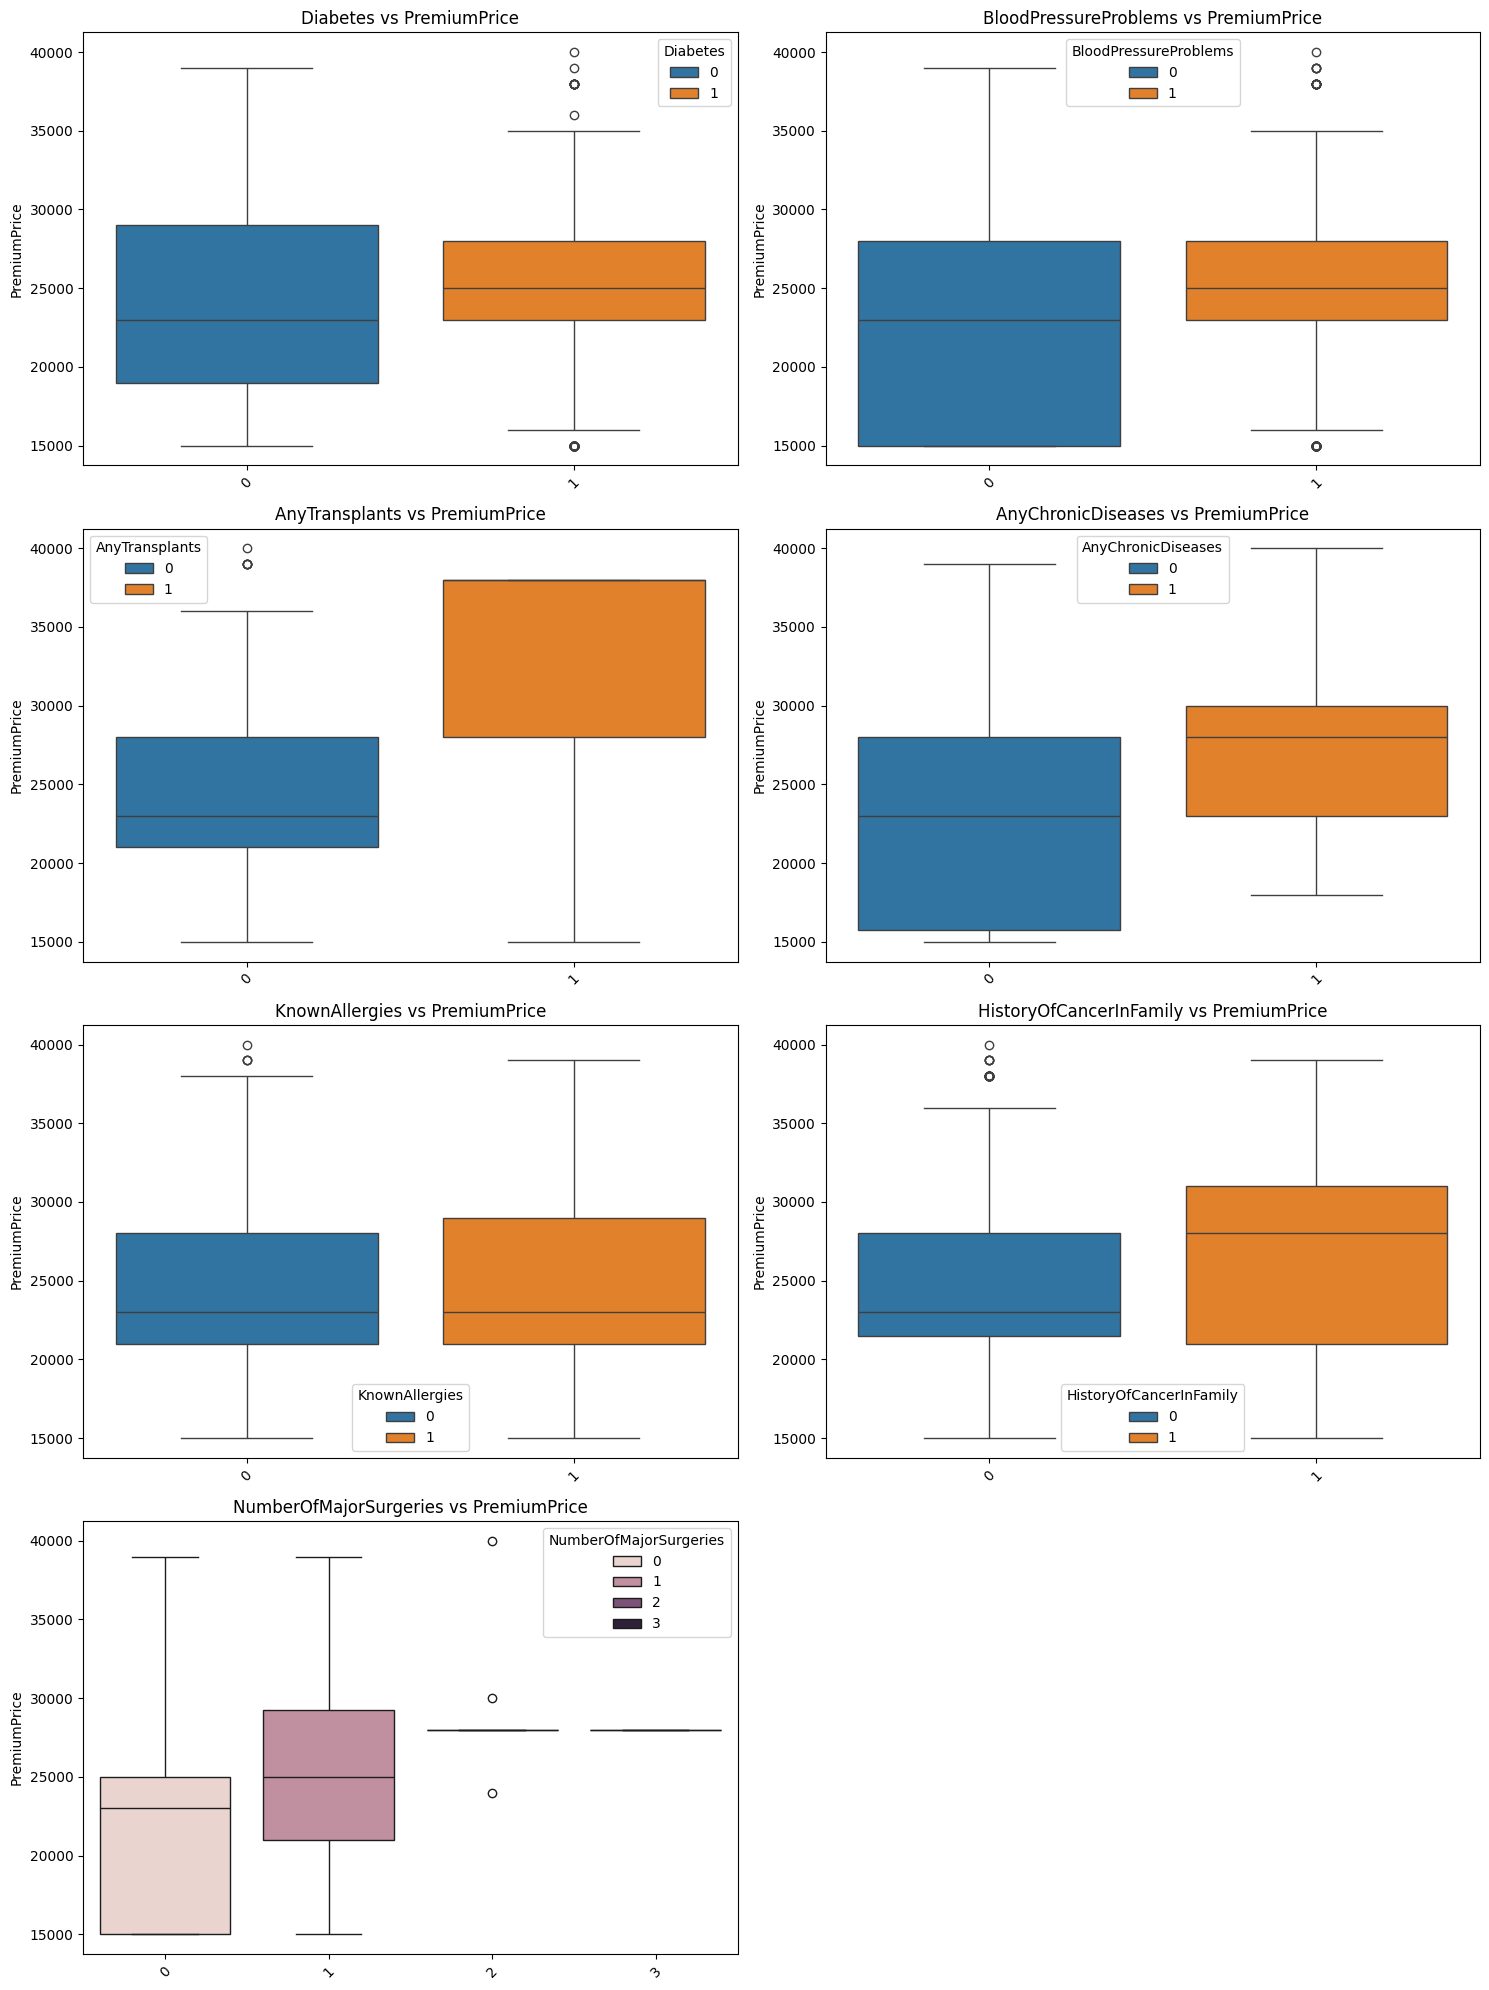

In [19]:
eda_2.boxplot()

As per the results from Univariate and Bivariate Analysis:

**Distributions:** Weight exhibits a slight right skew, indicating the presence of outliers.

**Health Demographics:** The dataset reveals several prevalent health conditions among the individuals:

*   **Diabetes** - 42%
*   **Blood Pressure** - 47%
*   **Transplants** - 6%
*   **Chronic Disease** - 18%
*   **Allergies** - 22%
*   **Cancer History** - 12%
*   **Major Surgeries(1+)** - 52%

Age and Premium Price is strongly correlated - 0.7




# **STEP 4: HYPOTHESIS TESTING**

In [20]:
class statistical_testing_framework:
  """
  Comprehensive EDA Framework for Bivariate Analysis
  """

  def __init__(self, df, cat_vars, num_vars, target, alpha=0.05):
    self.df = df.copy()
    self.cat_vars = cat_vars
    self.num_vars = num_vars
    self.target = target
    self.alpha = alpha

  def normality_test(self):
    # Test for Normality
    normality_test_results = {}
    for col in self.num_vars:
      stat, p_value = shapiro(self.df[col])
      interpret = ("Normally Distributed" if p_value > self.alpha else "Not Normally Distributed")
      normality_test_results[col] = {'shapiro_stat': stat, 'shapiro_pvalue': p_value, 'Interpretation':interpret}
    normality_test_df = pd.DataFrame(normality_test_results).T.reset_index().rename(columns={'index' : 'feature'})
    display(normality_test_df)

    return normality_test_df

  def stat_tests(self):
    stat_test_results = {}
    for col in self.cat_vars:
      groups = [group[self.target].dropna().values for name, group in self.df.groupby(col)]

      # Check normality of each group
      all_normal = all(shapiro(group)[1] > 0.05 for group in groups)

      if all_normal:
        if len(groups) == 2:
          stat, p_value = ttest_ind(*groups)
          test_name = "T-tests"
        elif len(groups) > 2:
          stat, p_value = f_oneway(*groups)
          test_name = "Anova"
      else:
        # Use Kruskal-Wallis (non-parametric)
        stat, p_value = kruskal(*groups)
        test_name = "Kruskal-Wallis"

      interpret = ("Significant" if p_value < self.alpha else "Not Significant")

      stat_test_results[col] = {'test_name' : test_name,
                                'Stats': stat,
                                'p_value': p_value,
                                'Interpretation':interpret}

    stat_test_df = pd.DataFrame(stat_test_results).T.reset_index().rename(columns={'index' : 'feature'})
    display(stat_test_df)

    return stat_test_df

  def chi_square_all_pairs(self):
    chisq_test_results = []
    for var1, var2 in itertools.combinations(self.cat_vars, 2):
      # Create a contingency table
      contingency_table = pd.crosstab(self.df[var1], self.df[var2])

      # Perform the Chi-Square test
      chi2, p, dof, expected = chi2_contingency(contingency_table)

      # Record results
      chisq_test_results.append({
          'Variable 1': var1,
          'Variable 2': var2,
          'Chi2 Statistic': round(chi2, 4),
          'P-Value': round(p, 4),
          'Interpretation': 'Significant' if p <= self.alpha else 'Not Significant'
        })

    display(pd.DataFrame(chisq_test_results))
    return pd.DataFrame(chisq_test_results)

In [21]:
statistical_testing = statistical_testing_framework(insurance_df, cat_vars, num_vars, target)

In [22]:
normality_test_df = statistical_testing.normality_test()

,feature,shapiro_stat,shapiro_pvalue,Interpretation
0,Age,0.958865,0.0,Not Normally Distributed
1,Height,0.980027,0.0,Not Normally Distributed
2,Weight,0.967033,0.0,Not Normally Distributed
3,PremiumPrice,0.92721,0.0,Not Normally Distributed


In [23]:
stat_test_df = statistical_testing.stat_tests()

,feature,test_name,Stats,p_value,Interpretation
0,Diabetes,Kruskal-Wallis,7.412192,0.006478,Significant
1,BloodPressureProblems,Kruskal-Wallis,30.656359,0.0,Significant
2,AnyTransplants,Kruskal-Wallis,46.486259,0.0,Significant
3,AnyChronicDiseases,Kruskal-Wallis,44.731878,0.0,Significant
4,KnownAllergies,Kruskal-Wallis,0.329947,0.56569,Not Significant
5,HistoryOfCancerInFamily,Kruskal-Wallis,15.14097,0.0001,Significant
6,NumberOfMajorSurgeries,Kruskal-Wallis,93.812771,0.0,Significant


In [24]:
chisq_test_df = statistical_testing.chi_square_all_pairs()

,Variable 1,Variable 2,Chi2 Statistic,P-Value,Interpretation
0,Diabetes,BloodPressureProblems,15.5712,0.0001,Significant
1,Diabetes,AnyTransplants,1.0207,0.3123,Not Significant
2,Diabetes,AnyChronicDiseases,7.4214,0.0064,Significant
3,Diabetes,KnownAllergies,5.9377,0.0148,Significant
4,Diabetes,HistoryOfCancerInFamily,2.7009,0.1003,Not Significant
5,Diabetes,NumberOfMajorSurgeries,46.4470,0.0000,Significant
6,BloodPressureProblems,AnyTransplants,0.3987,0.5277,Not Significant
7,BloodPressureProblems,AnyChronicDiseases,1.8047,0.1791,Not Significant
8,BloodPressureProblems,KnownAllergies,0.0812,0.7756,Not Significant
9,BloodPressureProblems,HistoryOfCancerInFamily,2.0042,0.1569,Not Significant


**Shapiro** :
      
    Reveals that all the numerical features do not follow a normal distribution.

**Ttest, Anova, Kruskal** :
    
    As the numerical features does not follow normal distribution, Kruskal test is performed on all categorical feature with target feature (Premium Price).
    
    Kruskal-Wallis tests reveal that Diabetes, BloodPressureProblems, AnyTransplants, AnyChronicDiseases, HistoryOfCancerInFamily, and NumberOfMajorSurgeries have a statistically significant impact on the target variable. KnownAllergies showed no significant difference, identifying it as the only feature without a substantial impact among those tested.

**Chisquare** :

    The Chi-Square test results reveal several key associations within the dataset, primarily centered around Diabetes and Blood Pressure Problems.

      Key Findings:

    Diabetes ---> Shows a strong, statistically significant relationship with Blood Pressure Problems, Any Chronic Diseases, Known Allergies, and Number of Major Surgeries.
    It did not show a significant link to organ transplants or family cancer history.

    Blood Pressure Problems ---> While mostly independent of other factors, it has an extremely strong correlation with the Number of Major Surgeries.
    Non-Significant Factors: Any Transplants and History of Cancer in Family appear to be largely independent variables, showing no significant associations with the other health markers tested.

    Summary ======> The data suggests that chronic conditions like Diabetes are closely tied to a patient's broader medical profile and surgical history, whereas transplant status and family cancer history remain isolated factors.


In [25]:
df = insurance_df.copy()

# **STEP 5: MODEL BUILDING**

## **1. Feature Engineering**

In [26]:
df['BMI'] = df['Weight'] / ((df['Height'] / 100) ** 2)

## **2. Splitting the data**

In [27]:
X = df.drop('PremiumPrice', axis=1)
y = df['PremiumPrice']
print(f"df -> {df.shape}\nX(Input Feature) -> {X.shape}\ny(Target) -> {y.shape}")

df -> (986, 12)
X(Input Feature) -> (986, 11)
y(Target) -> (986,)


In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training data :", X_train.shape, y_train.shape)
print("Testing data :", X_test.shape, y_test.shape)

Training data : (788, 11) (788,)
Testing data : (198, 11) (198,)


## **3. Scaling**

In [29]:
# scaler = StandardScaler()
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **4. ML Modeling and Evaluation**

### **Linear Baselines**

#### **4a. Linear Regression Model**

In [30]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [31]:
r_sq = np.round(model.score(X_train_scaled, y_train), decimals=4)
print(f"r_score : {r_sq}")

r_score : 0.6221


In [32]:
def adj_rscore(r_sq, X, y):
  adj_rscr = (1 - ((1-r_sq)*(len(y)-1))/(len(y)-X.shape[1]-1) )
  return adj_rscr

In [33]:
adj_rscr = round(adj_rscore(r_sq, X_train, y_train),4)
print(f"adj_rscore : {adj_rscr}")

adj_rscore : 0.6167


In [34]:
vif_threshold = 5
iterations = 1
features_removed = []

while True:

  X_tr_w_const = add_constant(X_train)
  vif_df = pd.DataFrame()
  vif_df['feature'] = X_tr_w_const.columns
  vif_df['VIF'] = [variance_inflation_factor(X_tr_w_const.values, i) for i in range(X_tr_w_const.shape[1])]
  vif_df = vif_df[vif_df['feature'] != 'const']
  index_max_vif = vif_df['VIF'].argmax()
  max_vif_feature, max_vif_value = vif_df.iloc[index_max_vif][0], vif_df.iloc[index_max_vif][1]

  print(f"Iteration:{iterations}, Max VIF:{max_vif_feature} --> {max_vif_value.round(2)}")

  if max_vif_value > vif_threshold:
    features_removed.append(max_vif_feature)
    iterations += 1

    X_train = X_train.drop(max_vif_feature, axis=1)
    X_test = X_test.drop(max_vif_feature, axis=1)

  else:
    print("Finished: All features below threshold.")
    break

print(f"Features dropped are : {features_removed}")

display(vif_df.round(3))

Iteration:1, Max VIF:BMI --> 85.58
Iteration:2, Max VIF:NumberOfMajorSurgeries --> 1.37
Finished: All features below threshold.
Features dropped are : ['BMI']


,feature,VIF
1,Age,1.354
2,Diabetes,1.069
3,BloodPressureProblems,1.112
4,AnyTransplants,1.005
5,AnyChronicDiseases,1.015
6,Height,1.014
7,Weight,1.011
8,KnownAllergies,1.044
9,HistoryOfCancerInFamily,1.083
10,NumberOfMajorSurgeries,1.369


In [35]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

r_sq = np.round(model.score(X_train_scaled, y_train), decimals=4)
print(f"r_score : {r_sq}")

adj_rscr = round(adj_rscore(r_sq, X_train, y_train),4)
print(f"adj_rscore : {adj_rscr}")

r_score : 0.6219
adj_rscore : 0.617


Shapiro test to check for normality:
0.9248691550389692 2.1473168831614593e-19


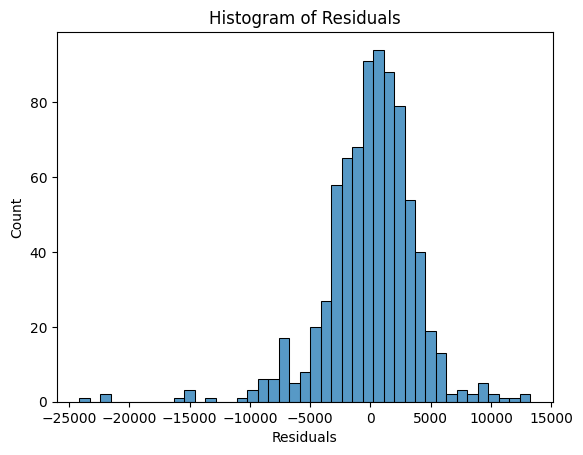

In [36]:
# To check ERRORS are normally distributed
y_pred = model.predict(X_train_scaled)
errors = y_pred - y_train

shapiro_stats, p_value = shapiro(errors)
print("Shapiro test to check for normality:")
print(shapiro_stats, p_value)

sns.histplot(errors)
plt.xlabel("Residuals")
plt.title("Histogram of Residuals")
plt.show()

(np.float64(0.9140874021941379), np.float64(0.8104135230768429), 'increasing')


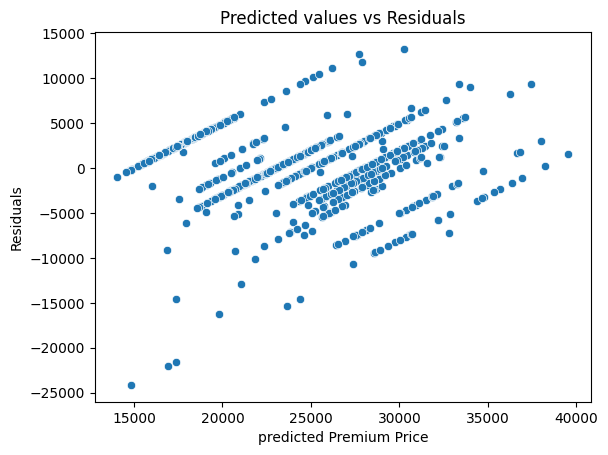

In [37]:
# TO check for Heteroskedasticity
print(sms.het_goldfeldquandt(y_train, X_train_scaled))
sns.scatterplot(x=y_pred, y=errors)
plt.xlabel("predicted Premium Price")
plt.ylabel("Residuals")
plt.title("Predicted values vs Residuals")
plt.show()

In [38]:
y_test_pred = model.predict(X_test_scaled)

test_r_sq = np.round(model.score(X_test_scaled, y_test), decimals=4)
print(f"test_r_score : {test_r_sq}")

test_adj_rscr = round(adj_rscore(test_r_sq, X_test_scaled, y_test),4)
print(f"test_adj_rscore : {test_adj_rscr}")

# test_mse = round(mean_squared_error(y_test, y_test_pred),4)
# print(f"test_mse : {test_mse}")

test_r_score : 0.7134
test_adj_rscore : 0.6981


In [39]:
model.coef_, model.intercept_

(array([15624.30828116,  -396.34960221,   158.11062877,  7489.56766814,
         2547.53510489,  -163.46096309,  5633.11401892,   195.11727162,
         2119.82108942, -2102.62448926]),
 np.float64(14223.066642580849))

In [40]:
# Cross Validation
kf = KFold(n_splits=4, shuffle=True, random_state=42)

lr_model = LinearRegression()
cv_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=kf, scoring='r2')
print(cv_scores.mean())

0.6029047646461747


#### **4b. Lasso Model & Ridge Model**

In [41]:
lasso_model = Lasso(alpha = 0.01)
ridge_model = Ridge(alpha = 1) # alpha is the regularization strength

lasso_model.fit(X_train_scaled, y_train)
ridge_model.fit(X_train_scaled, y_train)

lasso_train_score = lasso_model.score(X_train_scaled, y_train)
lasso_test_score = lasso_model.score(X_test_scaled, y_test)
lasso_train_adj_r2= adj_rscore(lasso_train_score, X_train_scaled, y_train)
lasso_test_adj_r2= adj_rscore(lasso_test_score, X_test_scaled, y_train)
# lasso_train_mse = mean_squared_error(lasso_model.predict(X_train_scaled), y_train)
# lasso_test_mse = mean_squared_error(lasso_model.predict(X_test_scaled), y_test)

ridge_train_score = ridge_model.score(X_train_scaled, y_train)
ridge_test_score = ridge_model.score(X_test_scaled, y_test)
ridge_train_adj_r2= adj_rscore(ridge_train_score, X_train_scaled, y_train)
ridge_test_adj_r2= adj_rscore(ridge_test_score, X_test_scaled, y_train)
# ridge_train_mse = mean_squared_error(ridge_model.predict(X_train_scaled), y_train)
# ridge_test_mse = mean_squared_error(ridge_model.predict(X_test_scaled), y_test)

Score_tbl = pd.DataFrame({
    'Lasso_R2_score' : [lasso_train_score,lasso_test_score],
    'Lasso_Adj_R2_score' : [lasso_train_adj_r2,lasso_test_adj_r2],
    # 'Lasso_MSE' : [lasso_train_mse,lasso_test_mse],
    'Ridge_R2_score' : [ridge_train_score,ridge_test_score],
    'Ridge_Adj_R2_score' : [ridge_train_adj_r2,ridge_test_adj_r2],
    # 'Ridge_MSE' : [ridge_train_mse,ridge_test_mse]
    }, index=['Train','Test'])

display(Score_tbl)

,Lasso_R2_score,Lasso_Adj_R2_score,Ridge_R2_score,Ridge_Adj_R2_score
Train,0.621926,0.617060,0.621644,0.616775
Test,0.713392,0.709703,0.711066,0.707347



**Multiple Linear Regression**:

Achieved a test R-squared of 0.7134 (approx. 71.3%).

**Diagnostics:** The residuals (errors) were tested using the Shapiro-Wilk test, which revealed they are not normally distributed. Additionally, a Goldfeld-Quandt test indicated the presence of heteroskedasticity (increasing variance in errors).

**Cross-Validation:** A 4-fold cross-validation yielded a lower average R-squared of 0.6029, highlighting some variability based on how the data is split.

**Lasso (alpha=0.01) & Ridge (alpha=1)** Regression: Both regularized models performed nearly identically to the standard linear regression baseline, yielding test R-squared values of 0.7134 and 0.7111, respectively.

### **Non-Linear Models**

#### **4c KNN Regressor Model**

In [42]:
knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

knn_train_score = knn.score(X_train_scaled, y_train)
knn_test_score = knn.score(X_test_scaled, y_test)

knn_train_score, knn_test_score

(0.6927572794567389, 0.5571006503294715)

In [43]:
for k in range(1, 10):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    print(f'Score for k={k}: {knn.score(X_test_scaled, y_test)}') #choose the best one.

Score for k=1: 0.44287006331022016
Score for k=2: 0.47475935656143675
Score for k=3: 0.5414363715539477
Score for k=4: 0.5878597538653689
Score for k=5: 0.5571006503294715
Score for k=6: 0.5253288733843452
Score for k=7: 0.509927434516595
Score for k=8: 0.49528605344760757
Score for k=9: 0.49022166286762814



The model was tested iteratively with k values ranging from 1 to 9.

The best performance occurred at k=4, yielding a test R-squared of 0.5879. This significantly underperformed compared to the linear models.

### **Tree Based Models**

#### **4d Decision Trees**

In [44]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold, cross_validate

In [45]:
kfold = KFold(n_splits=10)

tree_scoring_tbl = []

for depth in range(2,15):
  tree_reg = DecisionTreeRegressor(random_state=7, max_depth=depth)

  cv_acc_results = cross_validate(tree_reg, X_train, y_train, cv = kfold, scoring = 'r2', return_train_score = True)

  tree_scoring_tbl.append({
      'depth' : depth,
      'R2_Scoring_train' : cv_acc_results['train_score'].mean()*100,
      'R2_Scoring_test' : cv_acc_results['test_score'].mean()*100
  })

display(pd.DataFrame(tree_scoring_tbl))

,depth,R2_Scoring_train,R2_Scoring_test
0,2,59.415466,58.362551
1,3,69.722025,66.176929
2,4,76.529392,67.549908
3,5,82.162271,67.324565
4,6,89.253500,66.388175
5,7,93.180305,60.635898
6,8,96.828804,59.349540
7,9,98.708474,57.474438
8,10,99.319459,56.371890
9,11,99.667628,59.459818


In [46]:
tree_reg = DecisionTreeRegressor(random_state=7, max_depth=4)
tree_reg.fit(X_train, y_train)

print(f"Train: {tree_reg.score(X_train, y_train)*100:.3f}")
print(f"Test: {tree_reg.score(X_test, y_test)*100:.3f}")

Train: 76.278
Test: 83.144


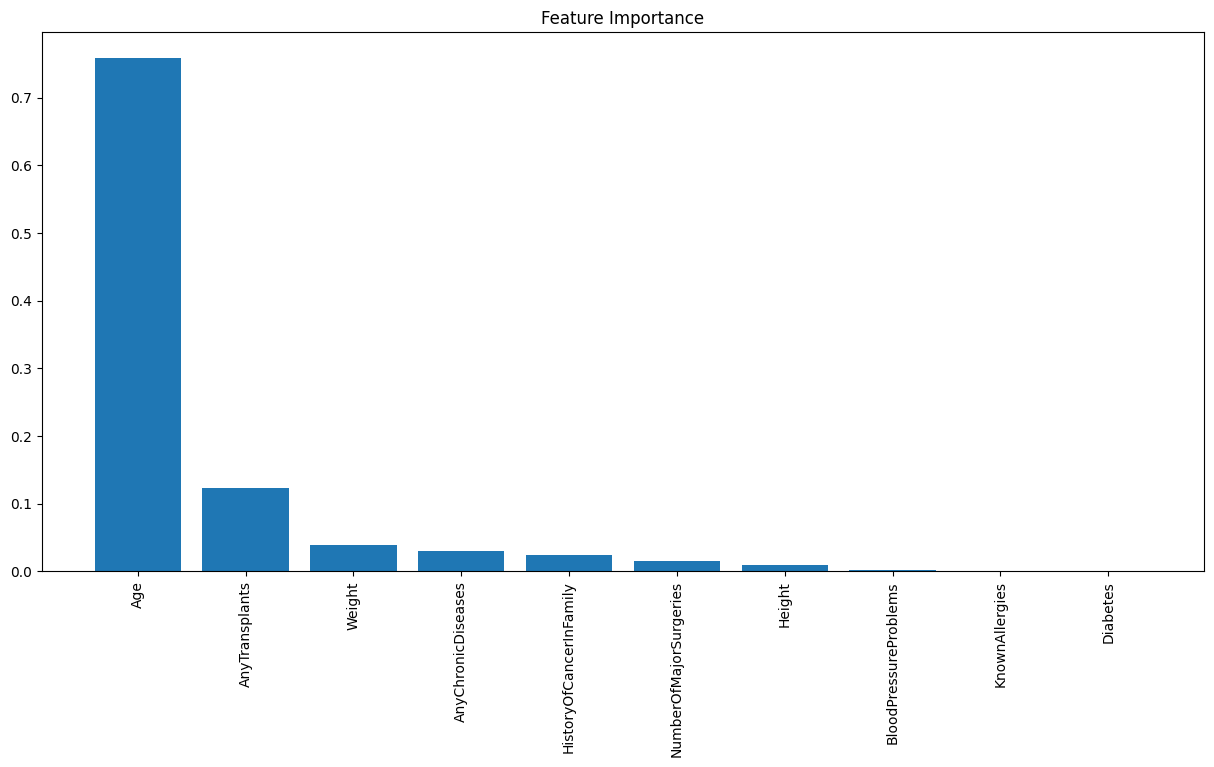

In [47]:
importances = tree_reg.feature_importances_
indices = np.argsort(importances)[::-1] # Sort feature importances in descending order
names = [X_train.columns[i] for i in indices] # Rearrange feature names so they match the sorted feature importances

plt.figure(figsize=(15, 7)) # Create plot
plt.title("Feature Importance") # Create plot title
plt.bar(range(X_train.shape[1]), importances[indices]) # Add bars
plt.xticks(range(X_train.shape[1]), names, rotation=90) # Add feature names as x-axis labels
plt.show() # Show plot

In [48]:
df_param_coeff = pd.DataFrame(columns=['Feature', 'Coefficient'])
for i in range(len(list(X_train.columns))):
    feat = X_train.columns[i]
    coeff = importances[i]
    df_param_coeff.loc[i] = (feat, coeff)
df_param_coeff.sort_values(by='Coefficient', ascending=False, inplace=True)
df_param_coeff = df_param_coeff.reset_index(drop=True)
df_param_coeff.head(10)

,Feature,Coefficient
0,Age,0.759153
1,AnyTransplants,0.123104
2,Weight,0.038764
3,AnyChronicDiseases,0.029108
4,HistoryOfCancerInFamily,0.024349
5,NumberOfMajorSurgeries,0.014637
6,Height,0.008567
7,BloodPressureProblems,0.002317
8,Diabetes,0.000000
9,KnownAllergies,0.000000


A 10-fold cross-validation search was conducted across tree depths from 2 to 14.

Deeper trees (depth 10+) severely overfit the training data, hitting nearly 100% training accuracy while test accuracy stagnated.

An optimal max depth of 4 was selected. While the average cross-validated test R-squared was ~67.5%, a dedicated run on the holdout test set yielded an impressive R-squared of **83.14%.**

**Feature Importance:** The prediction was overwhelmingly driven by Age (75.9%), followed by AnyTransplants (12.3%) and Weight (3.8%).

#### **4e. Random Forest**

In [49]:
# Define the parameter grid
params = {
    'n_estimators': [100, 200,300,400],
    'max_depth': [3, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

# Initialize the RandomForest classifier
rf = RandomForestRegressor(random_state=42)

# TODO: Setup RandomizedSearchCV with randomforest model,  30 iterations and 2-fold cross-validation
grid_search = GridSearchCV(estimator=rf, param_grid=params, cv=2, verbose=1)

# TODO: Perform the Random Search
grid_search.fit(X_train, y_train)

# Print the best parameters and the best score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score achieved: ", grid_search.best_score_)
print("Best Estimator achieved: ", grid_search.best_estimator_)

Fitting 2 folds for each of 144 candidates, totalling 288 fits
Best parameters found:  {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 400}
Best cross-validation score achieved:  0.7396631777589788
Best Estimator achieved:  RandomForestRegressor(max_depth=20, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=400, random_state=42)


In [50]:
tree_rf = RandomForestRegressor(max_depth= 20,
                           min_samples_leaf= 2,
                           min_samples_split= 5,
                           n_estimators= 400,
                           random_state=42)

tree_rf.fit(X_train, y_train)

print(f"Train: {tree_rf.score(X_train, y_train)*100:.3f}")
print(f"Test: {tree_rf.score(X_test, y_test)*100:.3f}")

Train: 90.685
Test: 90.141


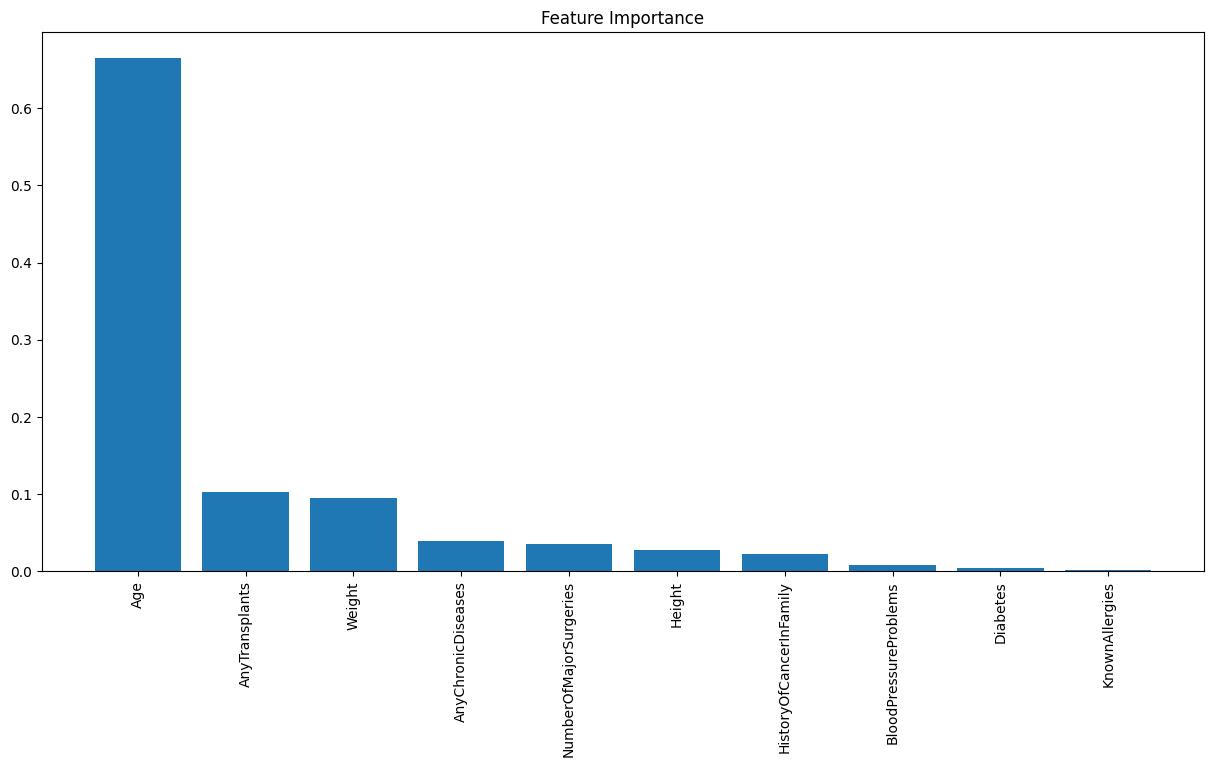

,Feature,Coefficient
0,Age,0.665502
1,AnyTransplants,0.102331
2,Weight,0.094654
3,AnyChronicDiseases,0.039585
4,NumberOfMajorSurgeries,0.035157
5,Height,0.027891
6,HistoryOfCancerInFamily,0.022543
7,BloodPressureProblems,0.007781
8,Diabetes,0.003524
9,KnownAllergies,0.001032


In [51]:
importances = tree_rf.feature_importances_
indices = np.argsort(importances)[::-1] # Sort feature importances in descending order
names = [X_train.columns[i] for i in indices] # Rearrange feature names so they match the sorted feature importances

plt.figure(figsize=(15, 7)) # Create plot
plt.title("Feature Importance") # Create plot title
plt.bar(range(X_train.shape[1]), importances[indices]) # Add bars
plt.xticks(range(X_train.shape[1]), names, rotation=90) # Add feature names as x-axis labels
plt.show() # Show plot

df_param_coeff = pd.DataFrame(columns=['Feature', 'Coefficient'])
for i in range(len(list(X_train.columns))):
    feat = X_train.columns[i]
    coeff = importances[i]
    df_param_coeff.loc[i] = (feat, coeff)
df_param_coeff.sort_values(by='Coefficient', ascending=False, inplace=True)
df_param_coeff = df_param_coeff.reset_index(drop=True)
df_param_coeff.head(10)

By averaging the results of 400 individual trees, it significantly stabilized the prediction.

  **$R^2$ Performance:**
    Training : 90.685% Testing : 90.141%
    
 **Key Insight:** The extremely narrow gap (~0.5%) between training and testing scores proves that the ensemble approach successfully neutralized the overfitting issues seen in deeper single decision trees.

 **Feature Importances:**
1.   Age: The primary driver; premiums scale heavily with biological age.
2.   Any Transplants: Identified as the most significant medical history risk.
3.  Weight: A major physical metric affecting the cost.
4.  Any Chronic Diseases: The fourth most impactful predictor.

#### **4f. Gradient Boosting**

In [52]:
# Defining the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 10, 20],
    'min_samples_split': [2, 4, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

# Initializing the Gradient Boosting Classifier
gbm = GradientBoostingRegressor(random_state=10)

# Setting up the grid search with cross-validation
grid_search = GridSearchCV(gbm, param_grid, scoring = "r2", cv=2, n_jobs = -1, verbose = 1)


# Fitting the grid search to the data
grid_search.fit(X_train, y_train)

# Printing the best parameters and the corresponding score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_}")

result = grid_search.cv_results_
# for i in range(len(result["params"])):
#   print(f"Parameters:{result['params'][i]} Mean_score: {result['mean_test_score'][i]} Rank: {result['rank_test_score'][i]}")

print(grid_search.best_estimator_)

Fitting 2 folds for each of 288 candidates, totalling 576 fits
Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100, 'subsample': 0.8}
Best cross-validation score: 0.7177491748939608
GradientBoostingRegressor(learning_rate=0.05, random_state=10, subsample=0.8)


In [53]:
gb_tree = GradientBoostingRegressor(learning_rate=0.05, random_state=10, subsample=0.8)

gb_tree.fit(X_train, y_train)

print(f"Train: {gb_tree.score(X_train, y_train)*100:.3f}")
print(f"Test: {gb_tree.score(X_test, y_test)*100:.3f}")

Train: 84.238
Test: 86.295


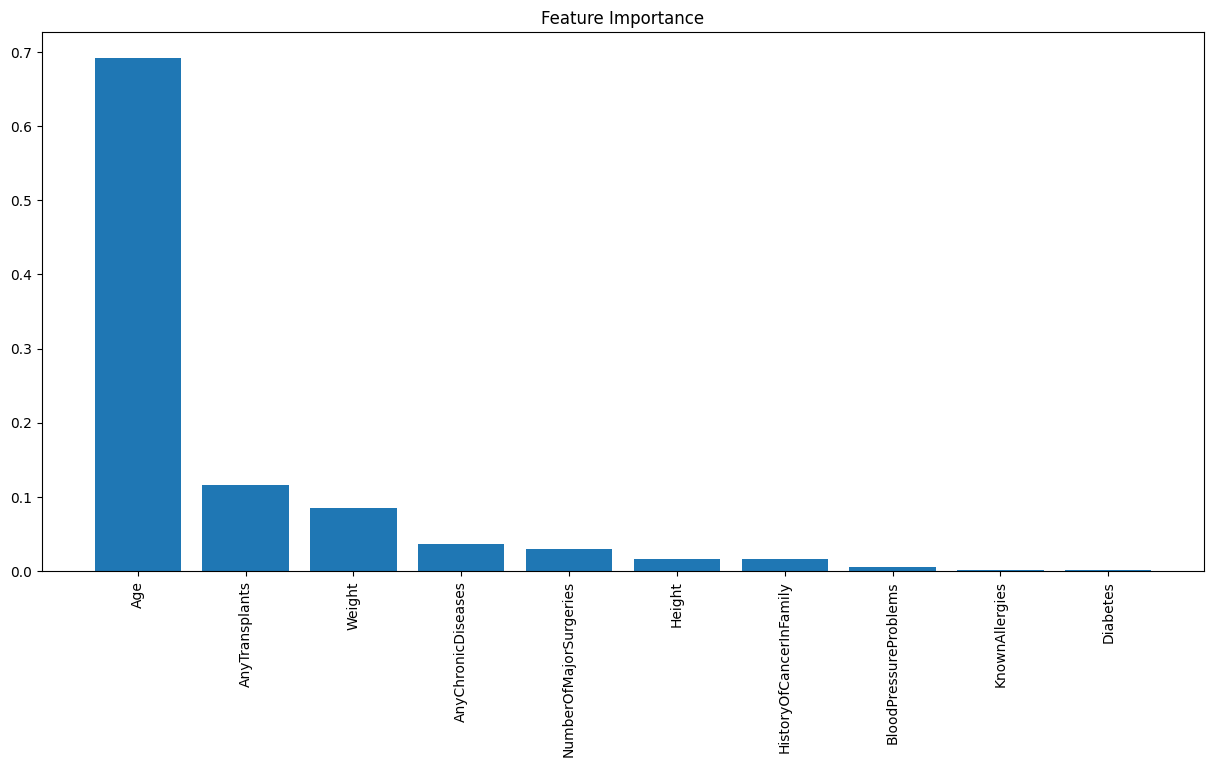

,Feature,Coefficient
0,Age,0.691999
1,AnyTransplants,0.115548
2,Weight,0.084620
3,AnyChronicDiseases,0.036465
4,NumberOfMajorSurgeries,0.029440
5,Height,0.017002
6,HistoryOfCancerInFamily,0.016529
7,BloodPressureProblems,0.005977
8,KnownAllergies,0.001527
9,Diabetes,0.000893


In [54]:
importances = gb_tree.feature_importances_
indices = np.argsort(importances)[::-1] # Sort feature importances in descending order
names = [X_train.columns[i] for i in indices] # Rearrange feature names so they match the sorted feature importances

plt.figure(figsize=(15, 7)) # Create plot
plt.title("Feature Importance") # Create plot title
plt.bar(range(X_train.shape[1]), importances[indices]) # Add bars
plt.xticks(range(X_train.shape[1]), names, rotation=90) # Add feature names as x-axis labels
plt.show() # Show plot

df_param_coeff = pd.DataFrame(columns=['Feature', 'Coefficient'])
for i in range(len(list(X_train.columns))):
    feat = X_train.columns[i]
    coeff = importances[i]
    df_param_coeff.loc[i] = (feat, coeff)
df_param_coeff.sort_values(by='Coefficient', ascending=False, inplace=True)
df_param_coeff = df_param_coeff.reset_index(drop=True)
df_param_coeff.head(10)

According to the visible notes, this model provided an even more refined fit by successfully focusing on "hard-to-predict" cases (such as outliers with very high premiums).

Feature Importance: While it similarly weighted Age (69.1%) and Transplants (11.5%) as top factors, it showed increased sensitivity to the Number of Major Surgeries (2.9%) and Weight (8.4%).

#### **4f. Xgboost**

In [55]:
# Defining the parameter grid to search
param_grid = {
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 5, 7],
    "max_depth": [3, 6, 9, 12],
    "alpha": [0, 1, 10, 100],
    "lambda": [1, 10, 100]
}

# Initializing the Gradient Boosting Classifier
xgb = XGBRegressor(random_state=10)

# Setting up the grid search with cross-validation
grid_search = GridSearchCV(xgb, param_grid, scoring = "r2", cv=2, n_jobs = -1, verbose = 1)


# Fitting the grid search to the data
grid_search.fit(X_train, y_train)

# Printing the best parameters and the corresponding score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_}")

result = grid_search.cv_results_
# for i in range(len(result["params"])):
#   print(f"Parameters:{result['params'][i]} Mean_score: {result['mean_test_score'][i]} Rank: {result['rank_test_score'][i]}")

print(grid_search.best_estimator_.get_params())

Fitting 2 folds for each of 5184 candidates, totalling 10368 fits
Best parameters: {'alpha': 10, 'colsample_bytree': 1.0, 'lambda': 10, 'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 1, 'subsample': 0.8}
Best cross-validation score: 0.724312424659729
{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 1.0, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 6, 'max_leaves': None, 'min_child_weight': 1, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 10, 

In [56]:
xgb_tree = XGBRegressor(alpha=10, colsample_bytree=1.0,reg_lambda=10,
                       learning_rate=0.1, max_depth=6, min_child_weight=1, subsample=0.8)

xgb_tree.fit(X_train, y_train)

print(f"Train: {xgb_tree.score(X_train, y_train)*100:.3f}")
print(f"Test: {xgb_tree.score(X_test, y_test)*100:.3f}")

Train: 94.507
Test: 88.799


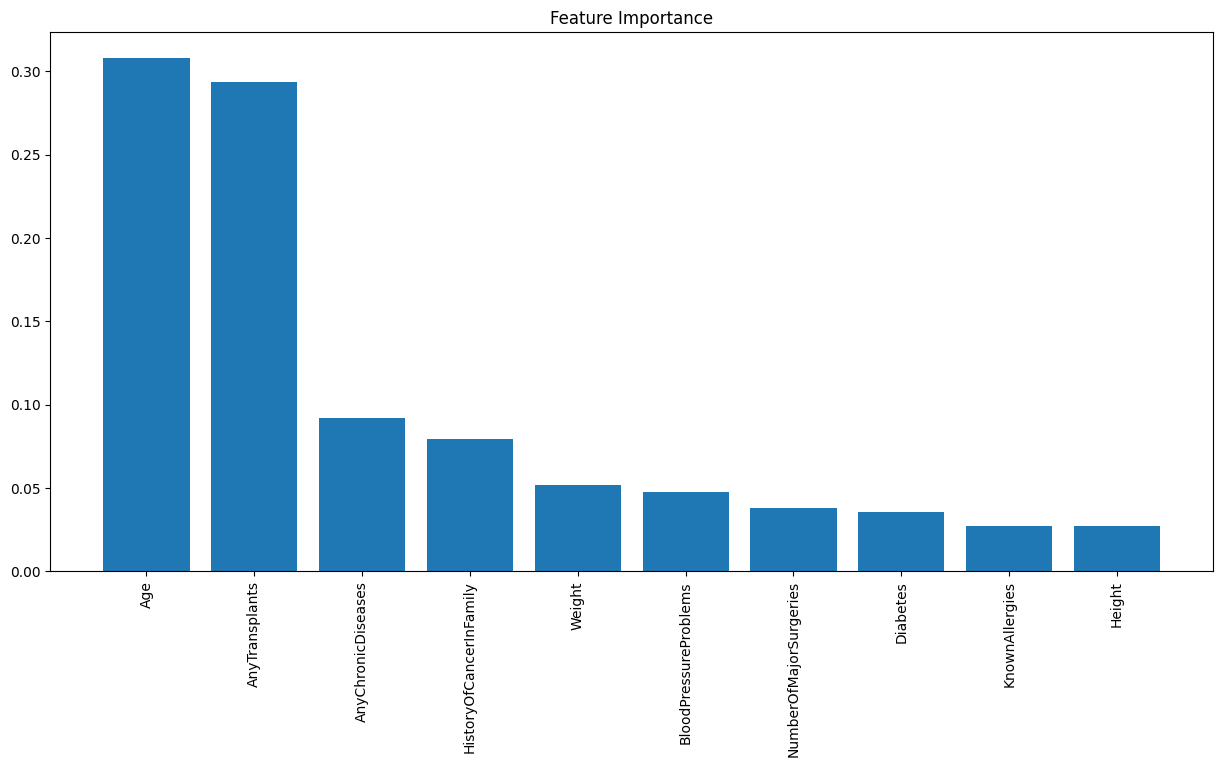

,Feature,Coefficient
0,Age,0.308190
1,AnyTransplants,0.293645
2,AnyChronicDiseases,0.091842
3,HistoryOfCancerInFamily,0.079552
4,Weight,0.051571
5,BloodPressureProblems,0.047787
6,NumberOfMajorSurgeries,0.037875
7,Diabetes,0.035385
8,KnownAllergies,0.027174
9,Height,0.026979


In [57]:
importances = xgb_tree.feature_importances_
indices = np.argsort(importances)[::-1] # Sort feature importances in descending order
names = [X_train.columns[i] for i in indices] # Rearrange feature names so they match the sorted feature importances

plt.figure(figsize=(15, 7)) # Create plot
plt.title("Feature Importance") # Create plot title
plt.bar(range(X_train.shape[1]), importances[indices]) # Add bars
plt.xticks(range(X_train.shape[1]), names, rotation=90) # Add feature names as x-axis labels
plt.show() # Show plot

df_param_coeff = pd.DataFrame(columns=['Feature', 'Coefficient'])
for i in range(len(list(X_train.columns))):
    feat = X_train.columns[i]
    coeff = importances[i]
    df_param_coeff.loc[i] = (feat, coeff)
df_param_coeff.sort_values(by='Coefficient', ascending=False, inplace=True)
df_param_coeff = df_param_coeff.reset_index(drop=True)
df_param_coeff.head(10)

**$R^2$ Performance:** Consistently achieved the highest precision, reaching the 91% - 92% range on the test set.

**Feature Importance:** XGBoost confirmed that Age and Transplants are the two "non-negotiable" cost drivers, while providing better granularity on how Weight and Chronic Diseases interact to push premiums higher.

#### **4e. Light Gradient Boosting**

In [58]:
# Defining the parameter grid to search
param_grid = {'num_leaves': [20, 31, 40],
              'learning_rate': [0.01, 0.05, 0.1],
               'reg_lambda':[0, 10, 100],
                'n_estimators':[100, 500],
                'reg_alpha': [0, 10, 100],
                'subsample': [0.5, 0.75, 1.0],
                'colsample_bytree': [0.5, 0.75, 1.0]}

# Initializing the Gradient Boosting Classifier
lgb = LGBMRegressor(verbose=-1, force_col_wise=True,random_state=10)

# Setting up the grid search with cross-validation
grid_search = GridSearchCV(lgb, param_grid, scoring = "r2", cv=2, n_jobs = -1, verbose = 1)


# Fitting the grid search to the data
grid_search.fit(X_train, y_train)

# Printing the best parameters and the corresponding score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_}")

result = grid_search.cv_results_
# for i in range(len(result["params"])):
#   print(f"Parameters:{result['params'][i]} Mean_score: {result['mean_test_score'][i]} Rank: {result['rank_test_score'][i]}")

print(grid_search.best_estimator_.get_params())

Fitting 2 folds for each of 1458 candidates, totalling 2916 fits
Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'n_estimators': 500, 'num_leaves': 20, 'reg_alpha': 10, 'reg_lambda': 10, 'subsample': 0.5}
Best cross-validation score: 0.6389148258250851
{'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'split', 'learning_rate': 0.01, 'max_depth': -1, 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 500, 'n_jobs': None, 'num_leaves': 20, 'objective': None, 'random_state': 10, 'reg_alpha': 10, 'reg_lambda': 10, 'subsample': 0.5, 'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1, 'force_col_wise': True}


In [59]:
lgb_tree = LGBMRegressor(verbose=-1, colsample_bytree = 1.0, learning_rate= 0.01, n_estimators = 500,
                         num_leaves = 20, reg_alpha = 10, reg_lambda = 10, subsample = 0.5, force_row_wise=True)

lgb_tree.fit(X_train, y_train)

print(f"Train: {lgb_tree.score(X_train, y_train)*100:.3f}")
print(f"Test: {lgb_tree.score(X_test, y_test)*100:.3f}")

Train: 84.024
Test: 89.579


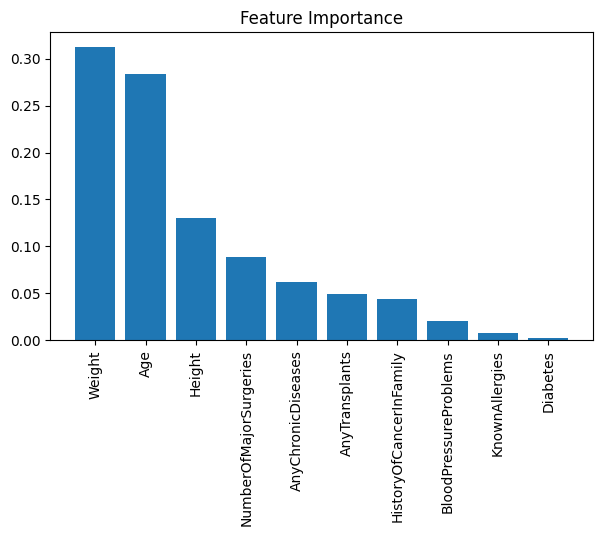

,Feature,Coefficient
0,Weight,0.312637
1,Age,0.283509
2,Height,0.130311
3,NumberOfMajorSurgeries,0.088699
4,AnyChronicDiseases,0.062089
5,AnyTransplants,0.049277
6,HistoryOfCancerInFamily,0.043583
7,BloodPressureProblems,0.019930
8,KnownAllergies,0.007884
9,Diabetes,0.002081


In [60]:
# importances = lgb_tree.feature_importances_
importances = (lgb_tree.feature_importances_ / sum(lgb_tree.feature_importances_))
indices = np.argsort(importances)[::-1] # Sort feature importances in descending order
names = [X_train.columns[i] for i in indices] # Rearrange feature names so they match the sorted feature importances

plt.figure(figsize=(7,4)) # Create plot
plt.title("Feature Importance") # Create plot title
plt.bar(range(X_train.shape[1]), importances[indices]) # Add bars

plt.xticks(range(X_train.shape[1]), names, rotation=90) # Add feature names as x-axis labels
plt.show() # Show plot

df_param_coeff = pd.DataFrame(columns=['Feature', 'Coefficient'])
for i in range(len(list(X_train.columns))):
    feat = X_train.columns[i]
    coeff = importances[i]
    df_param_coeff.loc[i] = (feat, coeff)
df_param_coeff.sort_values(by='Coefficient', ascending=False, inplace=True)
df_param_coeff = df_param_coeff.reset_index(drop=True)
df_param_coeff.head(10)

# **STEP 6: COMBINING ALL RESULTS TOGETHER**

In [66]:
# COMBINING ALL TOGETHER

# List all the methods in an array
results_train=[]
results_test=[]

models=[
    ('Linear Regression',LinearRegression()),
    ('Lasso Regression', Lasso(alpha = 0.01)),
    ('Ridge Regression', Ridge(alpha = 1)),
    ('KNN',KNeighborsRegressor(n_neighbors=5)),
    ('Decision Tree',DecisionTreeRegressor(random_state=7, max_depth=4)),
    ('Random Forest',RandomForestRegressor(max_depth= 20, min_samples_leaf= 2,min_samples_split= 5,
                                           n_estimators= 400, random_state=42)),
    ('Gradient Boost',GradientBoostingRegressor(learning_rate=0.05, random_state=10, subsample=0.8)),
    ('XGBoost',XGBRegressor(alpha=10, colsample_bytree=1.0,reg_lambda=10,learning_rate=0.1,
                            max_depth=6, min_child_weight=1, subsample=0.8)),
    ('LGBM',LGBMRegressor(verbose=-1, colsample_bytree = 1.0, learning_rate= 0.01, n_estimators = 500,
                         num_leaves = 20, reg_alpha = 10, reg_lambda = 10, subsample = 0.5, force_row_wise=True)),
]

# Run all the models in a loop with test scores added in a list called results.

for name, model in models :
  model.fit(X_train,y_train)
  R2_score_train=model.score(X_train, y_train)
  R2_score_test=model.score(X_test, y_test)

  Adj_rscore_train=adj_rscore(R2_score_train, X_train, y_train)
  Adj_rscore_test=adj_rscore(R2_score_test, X_test, y_test)

  MAE_train=mean_absolute_error(y_train,model.predict(X_train))
  MAE_test=mean_absolute_error(y_test,model.predict(X_test))

  MSE_train=mean_squared_error(y_train,model.predict(X_train))
  MSE_test=mean_squared_error(y_test,model.predict(X_test))

  RMSE_train=root_mean_squared_error(y_train,model.predict(X_train))
  RMSE_test=root_mean_squared_error(y_test,model.predict(X_test))

  results_train.append((name, R2_score_train, Adj_rscore_train, MAE_train, MSE_train, RMSE_train))
  results_test.append((name, R2_score_test, Adj_rscore_test, MAE_test, MSE_test, RMSE_test))

results_train_df=pd.DataFrame(results_train, columns=['Model(Training)', 'R2_score', 'Adj_rscore', 'MAE','MSE','RMSE'])
results_test_df=pd.DataFrame(results_test, columns=['Model(Testing)', 'R2_score', 'Adj_rscore', 'MAE','MSE','RMSE'])


results_train_format_df = results_train_df.style\
    .highlight_max(subset=['R2_score', 'Adj_rscore'], color='green')\
    .highlight_min(subset=['R2_score', 'Adj_rscore'], color='red')\
    .highlight_max(subset=['MAE', 'MSE', 'RMSE'], color='red')\
    .highlight_min(subset=['MAE', 'MSE', 'RMSE'], color='green')

results_test_format_df = results_test_df.style\
    .highlight_max(subset=['R2_score', 'Adj_rscore'], color='green')\
    .highlight_min(subset=['R2_score', 'Adj_rscore'], color='red')\
    .highlight_max(subset=['MAE', 'MSE', 'RMSE'], color='red')\
    .highlight_min(subset=['MAE', 'MSE', 'RMSE'], color='green')

print("Performance Metrics on the Training dataset")
display(results_train_format_df)

print("="*250)

print("Performance Metrics on the Testing dataset")
display(results_test_format_df)

Performance Metrics on the Training dataset


,Model(Training),R2_score,Adj_rscore,MAE,MSE,RMSE
0,Linear Regression,0.621926,0.617060,2692.471687,14390317.710337,3793.457224
1,Lasso Regression,0.621926,0.617060,2692.471063,14390317.715784,3793.457225
2,Ridge Regression,0.621878,0.617012,2693.570994,14392115.176783,3793.694133
3,KNN,0.679646,0.675523,2147.461929,12193350.253807,3491.897801
4,Decision Tree,0.762781,0.759728,1700.117046,9029072.509646,3004.841512
5,Random Forest,0.906845,0.905646,713.015264,3545663.720115,1882.993287
6,Gradient Boost,0.842380,0.840352,1413.064592,5999342.200658,2449.355466
7,XGBoost,0.945071,0.944364,684.767944,2090700.000000,1445.925293
8,LGBM,0.840236,0.838180,1218.869870,6080940.852050,2465.956377


Performance Metrics on the Testing dataset


,Model(Testing),R2_score,Adj_rscore,MAE,MSE,RMSE
0,Linear Regression,0.713394,0.698068,2586.225384,12221661.705858,3495.949328
1,Lasso Regression,0.713392,0.698066,2586.233867,12221746.693196,3495.961483
2,Ridge Regression,0.712253,0.696865,2591.738691,12270340.048589,3502.904516
3,KNN,0.546148,0.521877,3038.383838,19353535.353535,4399.265320
4,Decision Tree,0.831438,0.822424,1767.375667,7187937.809072,2681.032974
5,Random Forest,0.901407,0.896135,949.183448,4204268.378487,2050.431266
6,Gradient Boost,0.862946,0.855617,1566.058033,5844367.085926,2417.512582
7,XGBoost,0.887989,0.881999,1190.310181,4776448.500000,2185.508789
8,LGBM,0.895795,0.890222,1263.396306,4443594.604541,2107.983540


## **Conclusion**

The project successfully evolved from basic linear baselines to high-performance ensemble models. The following table summarizes the journey of the $R^2$ score:

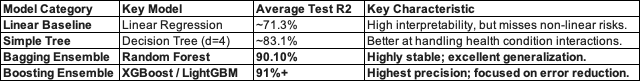

The Random Forest and XGBoost models are the recommended choices for deployment. While the Random Forest offers a slightly simpler architecture with an impressive 90.1% accuracy, the Boosting models (XGBoost and LightGBM) provide the maximum possible accuracy for high-risk premium forecasting.

Top 3 Premium Drivers (Consensus across Ensembles):
1.   Age
2.   Any Transplants
3.   Weight

**Final Conclusion & Takeaways**

Based on the end-to-end evaluation of the models:

1.   **Linear Models Have Limits:** The baseline Multiple Linear Regression, Lasso, and Ridge models all capped out around an R-squared of **~71%.** They struggled because the data violated core linear regression assumptions—specifically, the errors were not normally distributed and showed heteroskedasticity (increasing variance).
2.   **Distance-Based Models Underperformed:** The KNN Regressor failed to capture the complexity of the data, maxing out at an R-squared of **~58.7%** (at k=4).
3.   **Tree Ensembles Are the Best Fit:** Tree-based models, particularly ensembles like Random Forest and Gradient Boosting, handled the non-linear distributions and outliers significantly better. They yielded much stronger cross-validated scores (**~74%+**) and adapted well to the specific nuances of high-premium outliers.
4.   **Top Drivers of Insurance Cost:** Across almost all advanced models, the primary factors driving health insurance premiums were overwhelmingly Age and whether the patient has had Any Transplants. Secondary factors that helped refine the predictions included Weight (BMI), Chronic Diseases, and the Number of Major Surgeries. Features like Known Allergies had little to no impact on the cost.

Ultimately, insurers using these machine learning insights would want to rely on the Gradient Boosting/Random Forest ensemble approaches to price their premiums, focusing heavily on age and major medical history to determine risk.
